# 0. Import our libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# pd.options.display.float_format = '{:,.2f}'.format


# 1. Collecting data
- What subject is your data about? What is the source of your data?  
- Do authors of this data allow you to use like this? You can check the data license  
- How did authors collect data?


## About dataset
### Subject: Commercial flight operations in the United States (2024)

Although air travel is essential for bringing people and economies together, passenger flights are frequently disrupted by delays and cancellations. With over 1 million flights nationwide, this dataset offers a thorough understanding of US airline performance in 2024.

The dataset, which includes comprehensive statistics on departure times, cancellations, flight distances, weather delays, and late aircraft delays, presents a special chance to investigate

It represents the **real-world operation and reliability of the U.S. commercial airline system in 2024**, showing how weather, airline operations, and airport congestion cause **flight delays and cancellations that affect passengers and the national economy**.


### Sources
Kaggle link: [Flight Delay & Cancellation Data (1 Million+ 2024)](https://www.kaggle.com/datasets/nalisha/flight-delay-and-cancellation-data-1-million-2024) \
The On-Time Performance Data (2024) from the US Bureau of Transportation Statistics (BTS) is the source of this dataset. The source offers comprehensive details on airline on-time performance, including departure times, weather-related disruptions, delays, and cancellations.


**Publication date:** 8 Oct 2025

## Data Lisence

**No Copyright** 

The person who associated a work with this deed has dedicated the work to the public domain by waiving all of his or her rights to the work worldwide under copyright law, including all related and neighboring rights, to the extent allowed by law. 

You can copy, modify, distribute and perform the work, even for commercial purposes, all without asking permission. See Other Information via the link below. 

[CC0: Public Domain](https://creativecommons.org/publicdomain/zero/1.0/)



## Collection Methodology

The information was gathered from the 2024 On-Time Performance reports published by the US Bureau of Transportation Statistics (BTS). A single CSV file containing important features, such as delays, cancellations, distances, and weather impacts, was created by merging, cleaning, and curating monthly reports.



* **Target population & sampling:**
  **All scheduled domestic commercial passenger flights in the United States** operated by reporting carriers. This is **near-census data**, not a sample.

* **Time period:**
  **Calendar year 2024** (January–December).

* **Known limitations / biases:**

  * Includes **domestic flights only** (no international legs).
  * Smaller carriers or certain charter flights may be excluded.
  * Delay reasons are **self-reported by airlines**, which may introduce reporting bias.
  * Weather delay attribution can be imperfect or overlapping with other causes.
  * Does not capture passenger-level impacts (missed connections, rebooking experience).


## Why did we choose this dataset?
- What interests your group about this topic?
- What potential questions or insights could this data provide?


**Why we chose this dataset:**

* **Interest:**
  Flight delays and cancellations directly affect millions of passengers and reflect how a large, complex transportation system operates under real-world constraints such as weather, congestion, and limited resources.

* **Potential questions / insights:**

  * What are the main causes of delays and cancellations in U.S. flights?
  * Which airlines, airports, or routes are most reliable?
  * How do weather and late aircraft delays propagate across the network?
  * Can delays or cancellations be predicted in advance using historical patterns?


# 2. Exploring data 
- How many rows and how many columns?  
- What is the meaning of each row?  
- Are there **<span style="color:red">duplicated rows</span>**?  
- What is the meaning of each column?  
- What is the current data type of each column? Are there columns having **<span style="color:red">inappropriate data types</span>**?  
- With each numerical column, how are values distributed?  
  - What is the percentage of **<span style="color:red">missing values</span>**?  
  - Min? max? Are they **<span style="color:red">abnormal</span>**?  
- With each categorical column, how are values distributed?  
  - What is the percentage of **<span style="color:red">missing values</span>**?  
  - How many different values? Show a few  
  - Are they **<span style="color:red">abnormal</span>**?

## 2.1. Basic Information
- How many rows does your dataset have?
- How many columns does your dataset have?
- What does each row represent? (e.g., one customer, one transaction, one day)
- What is the overall size of the dataset?


#### Get to know our dataframe first!!

In [2]:
df = pd.read_csv("data/flight_data_2024.csv")
df.head(10)

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,1318.0,1442.0,7.0,0,84.0,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,1021.0,1249.0,6.0,0,88.0,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,1432.0,1533.0,8.0,0,61.0,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,1656.0,1747.0,12.0,0,51.0,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,1031.0,1016.0,4.0,0,45.0,237,0,0
5,2024,1,1,1,1/1/2024,JAX,"Jacksonville, FL",Florida,1403.0,14.0,1417.0,1559.0,4.0,0,102.0,833,0,0
6,2024,1,1,1,1/1/2024,LGA,"New York, NY",New York,947.0,26.0,1013.0,1218.0,13.0,0,125.0,833,0,0
7,2024,1,1,1,1/1/2024,CHS,"Charleston, SC",South Carolina,1135.0,8.0,1143.0,1309.0,5.0,0,86.0,641,0,0
8,2024,1,1,1,1/1/2024,LGA,"New York, NY",New York,810.0,14.0,824.0,1005.0,8.0,0,101.0,641,0,0
9,2024,1,1,1,1/1/2024,ITH,"Ithaca/Cortland, NY",New York,1248.0,12.0,1300.0,1343.0,12.0,0,43.0,189,0,0


In [3]:
df.tail()

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
1048570,2024,2,29,4,2/29/2024,SJU,"San Juan, PR",Puerto Rico,1447.0,24.0,1511.0,1640.0,7.0,0,149.0,1045,0,0
1048571,2024,2,29,4,2/29/2024,PHX,"Phoenix, AZ",Arizona,59.0,12.0,111.0,647.0,3.0,0,216.0,1972,0,105
1048572,2024,2,29,4,2/29/2024,JAX,"Jacksonville, FL",Florida,2014.0,20.0,2034.0,2128.0,10.0,0,54.0,328,0,0
1048573,2024,2,29,4,2/29/2024,CLT,"Charlotte, NC",North Carolina,1104.0,12.0,1116.0,1210.0,7.0,0,114.0,808,0,70
1048574,2024,2,29,4,2/29/2024,MCI,"Kansas City, MO",Missouri,1307.0,13.0,1320.0,1559.0,22.0,0,99.0,808,0,104


In [4]:
df.shape

(1048575, 18)

- **This dataset** has **1 048 757** rows and **18** columns
* **Each row represents:** a single flight (one origin to one destination) in the time‐span covered by the dataset.

* **Overall size of the dataset:**
  **Over 1 million flight records**, with **dozens of variables** covering timing, delays, cancellations, distance, airline, airport, and delay causes.


## 2.2. Data Integrity
- Are there any duplicated rows? If yes, how many?
- Should duplicates be kept or removed? (Justify your decision)
- Are all rows complete, or are some entirely empty?

In [5]:
dup_mask = df.duplicated(keep=False) 
dup_count_all = int(dup_mask.sum())
dup_count_excl_first = int(df.duplicated(keep='first').sum())

print(f"Total duplicated rows (including first occurrences marked): {dup_count_all}")
print(f"Duplicated rows excluding the first occurrence (to be removed if needed): {dup_count_excl_first}")

Total duplicated rows (including first occurrences marked): 11664
Duplicated rows excluding the first occurrence (to be removed if needed): 7401


In [6]:
df_no_dups = df.drop_duplicates().copy()
print(f"Rows after drop_duplicates(): {len(df_no_dups)} (was {len(df)})")

Rows after drop_duplicates(): 1041174 (was 1048575)


In [7]:
all_na_rows_mask = df.isna().all(axis=1)
all_na_rows_count = int(all_na_rows_mask.sum())
print(f"Rows that are entirely empty (all NaN value): {all_na_rows_count}")

df_clean = df_no_dups.loc[~all_na_rows_mask].copy()
print(f"Rows after removing entirely empty rows: {len(df_clean)}")

Rows that are entirely empty (all NaN value): 0
Rows after removing entirely empty rows: 1041174


### Data Integrity — Summary
- Duplicated rows: 11664
- Decision on duplicates: exact duplicates provide no new information and can bias aggregate statistics; we remove them via `df.drop_duplicates()`.
- Entirely empty rows: reported above; if any exist, they are removed.
- Clean working frame for subsequent steps: `df_clean` (duplicates dropped and empty rows removed).

## 2.3. Column Inventory
- What is the meaning/definition of each column?
- Which columns are relevant to potential analysis?
- Are there any columns that should be dropped? Why?

### 1. The meaning of each column?
| **Column name**         | **Meaning**                                                                                                           |
| ----------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **year**                | The year when the flight occurred (e.g., 2024).                                                                       |
| **month**               | The month number (1 = January, 12 = December).                                                                        |
| **day_of_month**        | The day of the month (1–31).                                                                                          |
| **day_of_week**         | The weekday number (1 = Monday, 7 = Sunday).                                                                          |
| **fl_date**             | The full flight date (month/day/year).                                                                                |
| **origin**              | The **IATA code** of the origin airport (e.g., JFK = John F. Kennedy International Airport).                          |
| **origin_city_name**    | The full city and state of the origin airport (e.g., “New York, NY”).                                                 |
| **origin_state_nm**     | The full name of the U.S. state where the origin airport is located (e.g., “New York”).                               |
| **dep_time**            | The **actual departure time** in local time, usually given in HHMM format (e.g., 1247 → 12:47 PM).                    |
| **taxi_out**            | The number of minutes the aircraft spent **taxiing on the ground before takeoff** (from gate pushback to wheels-off). |
| **wheels_off**          | The actual **time when the aircraft lifted off the runway**, in HHMM local time.                                      |
| **wheels_on**           | The actual **time when the aircraft touched down at the destination**, in HHMM local time.                            |
| **taxi_in**             | The number of minutes spent **taxiing after landing** (from touchdown to gate arrival).                               |
| **cancelled**           | A binary indicator: **0 = not cancelled**, **1 = cancelled**.                                                         |
| **air_time**            | The **total time in the air** (in minutes), equal to `wheels_on - wheels_off` (converted).                            |
| **distance**            | The great-circle **distance between origin and destination** (in miles).                                              |
| **weather_delay**       | Minutes of delay caused by **weather-related issues** (0 if none).                                                    |
| **late_aircraft_delay** | Minutes of delay caused by the **late arrival of the same aircraft** from a previous flight (0 if none).              |


In [8]:
df_clean.head()

,year,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,wheels_off,wheels_on,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,1318.0,1442.0,7.0,0,84.0,509,0,0
1,2024,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,1021.0,1249.0,6.0,0,88.0,622,0,0
2,2024,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,1432.0,1533.0,8.0,0,61.0,288,0,0
3,2024,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,1656.0,1747.0,12.0,0,51.0,288,0,0
4,2024,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,1031.0,1016.0,4.0,0,45.0,237,0,0


### 2. Which columns are relevant to potential analysis?

Most columns are relevant for analyzing **flight performance, delays, and operational efficiency**.

- **Time-based analysis**: `fl_date`, `day_of_week`, `month`
- **Location-based analysis**: `origin`, `origin_city_name`, `origin_state_nm`
- **Operational analysis**: `dep_time`, `taxi_out`, `taxi_in`, `wheels_off`, `wheels_on`, `air_time`
- **Delay and outcome analysis**: `cancelled`, `weather_delay`, `late_aircraft_delay`
- **Control variable**: `distance`

These columns allow the analysis of delay patterns across time, airports, and operational conditions.

### 3. Are there any columns that should be dropped? Why?

Some columns contain **redundant information** and may be removed depending on the analysis goal.

- `year`, `month`, `day_of_month` can be dropped if `fl_date` is used, as they are derived from the same date information.
- `origin_state_nm` may be redundant if `origin_city_name` is sufficient for location-based analysis.
- `wheels_off` and `wheels_on` may be dropped if only `air_time` is required.

However, no columns must be strictly removed, the decision depends on the specific analytical or modeling objectives.


Because everyone knows that the dataset was collected of lights in year 2024, so we can drop `year` column, `wheels_off` and `wheels_on` also can be dropped, because We just want to know how many minutes that customers spend being on air! 

In [9]:
df_clean = df_clean.drop(columns=["year", "wheels_off", "wheels_on"])
df_clean.head()

,month,day_of_month,day_of_week,fl_date,origin,origin_city_name,origin_state_nm,dep_time,taxi_out,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay
0,1,1,1,1/1/2024,JFK,"New York, NY",New York,1247.0,31.0,7.0,0,84.0,509,0,0
1,1,1,1,1/1/2024,MSP,"Minneapolis, MN",Minnesota,1001.0,20.0,6.0,0,88.0,622,0,0
2,1,1,1,1/1/2024,JFK,"New York, NY",New York,1411.0,21.0,8.0,0,61.0,288,0,0
3,1,1,1,1/1/2024,RIC,"Richmond, VA",Virginia,1643.0,13.0,12.0,0,51.0,288,0,0
4,1,1,1,1/1/2024,DTW,"Detroit, MI",Michigan,1010.0,21.0,4.0,0,45.0,237,0,0


### Data Types
- What is the current data type of each column?
- Are there columns with inappropriate data types?
- Which columns need type conversion?

In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1041174 entries, 0 to 1048574
Data columns (total 15 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   month                1041174 non-null  int64  
 1   day_of_month         1041174 non-null  int64  
 2   day_of_week          1041174 non-null  int64  
 3   fl_date              1041174 non-null  object 
 4   origin               1041174 non-null  object 
 5   origin_city_name     1041174 non-null  object 
 6   origin_state_nm      1041174 non-null  object 
 7   dep_time             1026022 non-null  float64
 8   taxi_out             1025450 non-null  float64
 9   taxi_in              1024898 non-null  float64
 10  cancelled            1041174 non-null  int64  
 11  air_time             1022824 non-null  float64
 12  distance             1041174 non-null  int64  
 13  weather_delay        1041174 non-null  int64  
 14  late_aircraft_delay  1041174 non-null  int64  
dtypes: 

We think that: flight date (fl_date) and actual departure time (dep_time) have inappropriate data type.
- We want to combine it together into **date and time departure of light** which has datetime data type

In [11]:
df_clean["fl_date"] = pd.to_datetime(df_clean["fl_date"], errors='coerce')

df_clean["dep_time_str"] = (
    df_clean["dep_time"]
    .astype("Int64")      # This allows NaNs to stay NaNs
    .astype(str)          # NaNs become the string "<NA>"
    .replace("<NA>", np.nan) # Change them back to real NaNs
    .str.zfill(4)         # Pad the valid numbers
)

In [12]:
df_clean["date_time_dep"] = pd.to_datetime(
    df_clean["fl_date"].dt.strftime("%Y-%m-%d") + " " +
    df_clean["dep_time_str"].str[:2] + ":" +
    df_clean["dep_time_str"].str[2:],
    errors="coerce"
)

In [13]:
df_clean.drop(columns=["dep_time_str", "fl_date", "dep_time"], inplace=True)


In [14]:
df_clean.head()

,month,day_of_month,day_of_week,origin,origin_city_name,origin_state_nm,taxi_out,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay,date_time_dep
0,1,1,1,JFK,"New York, NY",New York,31.0,7.0,0,84.0,509,0,0,2024-01-01 12:47:00
1,1,1,1,MSP,"Minneapolis, MN",Minnesota,20.0,6.0,0,88.0,622,0,0,2024-01-01 10:01:00
2,1,1,1,JFK,"New York, NY",New York,21.0,8.0,0,61.0,288,0,0,2024-01-01 14:11:00
3,1,1,1,RIC,"Richmond, VA",Virginia,13.0,12.0,0,51.0,288,0,0,2024-01-01 16:43:00
4,1,1,1,DTW,"Detroit, MI",Michigan,21.0,4.0,0,45.0,237,0,0,2024-01-01 10:10:00


## 2.4. Numerical Columns Analysis

### Distribution & Central Tendency
- What is the distribution shape? (normal, skewed, bimodal, uniform)
- Create visualizations: histograms, box plots, density plots,…
- Calculate: mean, median, standard deviation

In [15]:

numeric_cols = [
     'taxi_out', 'taxi_in', 'air_time', 'distance','weather_delay', 'late_aircraft_delay'
]

In [16]:
stats = df_clean[numeric_cols].agg(['mean', 'median', 'std', 'skew', 'kurt']).T
print("Basic statistics (mean, median, std, skew, kurt):")
stats


Basic statistics (mean, median, std, skew, kurt):


,mean,median,std,skew,kurt
taxi_out,18.250121,15.0,10.440251,3.516318,22.623252
taxi_in,8.082517,6.0,6.512591,5.666713,95.551071
air_time,116.226956,100.0,70.912036,1.453864,2.928183
distance,835.027019,693.0,592.697875,1.494688,3.116085
weather_delay,1.202810,0.0,20.129097,35.038225,1668.506463
late_aircraft_delay,5.364523,0.0,29.858931,15.747615,452.291327


In [17]:

shape_summary = {}
for c in numeric_cols:
    skew = df[c].skew()
    kurt = df[c].kurt()
    if np.isnan(skew):
        shape = 'insufficient data'
    else:
        if abs(skew) < 0.5:
            shape = 'approximately symmetric'
        elif skew > 0.5:
            shape = 'right-skewed (long right tail)'
        else:
            shape = 'left-skewed (long left tail)'
    peakness = 'heavy tails/high peak' if kurt > 3 else ('light tails/flat' if kurt < 3 else 'mesokurtic')
    shape_summary[c] = {'shape': shape, 'kurtosis_hint': peakness}

print("\nDistribution shape summary (by skew/kurt hints):")
for c, s in shape_summary.items():
    print(f"{c}: \n  | {s['shape']} \n  | {s['kurtosis_hint']} \n -------")



Distribution shape summary (by skew/kurt hints):
taxi_out: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------
taxi_in: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------
air_time: 
  | right-skewed (long right tail) 
  | light tails/flat 
 -------
distance: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------
weather_delay: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------
late_aircraft_delay: 
  | right-skewed (long right tail) 
  | heavy tails/high peak 
 -------


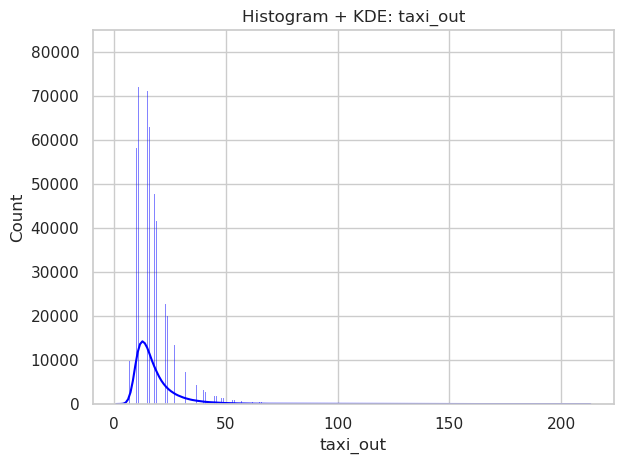

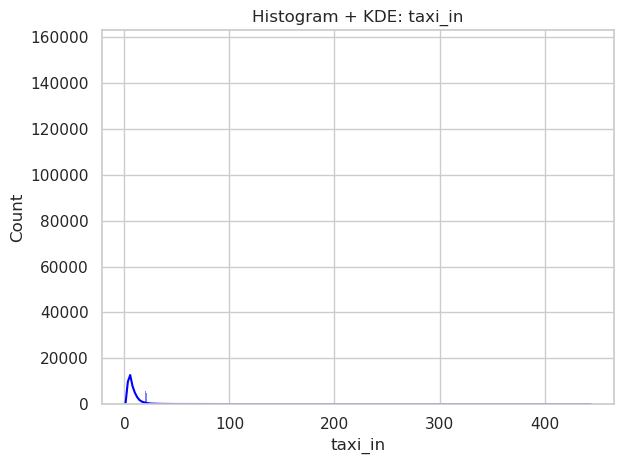

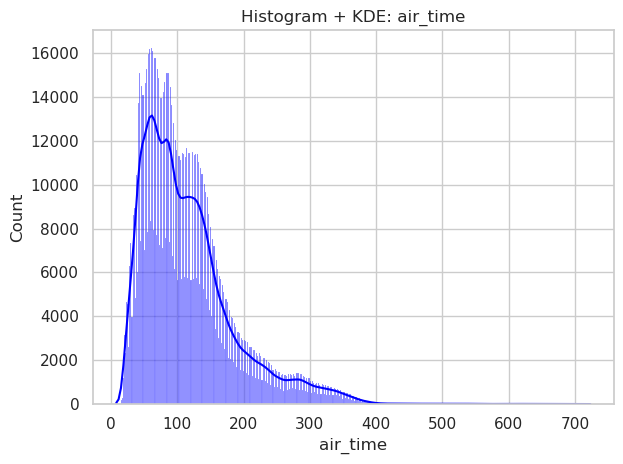

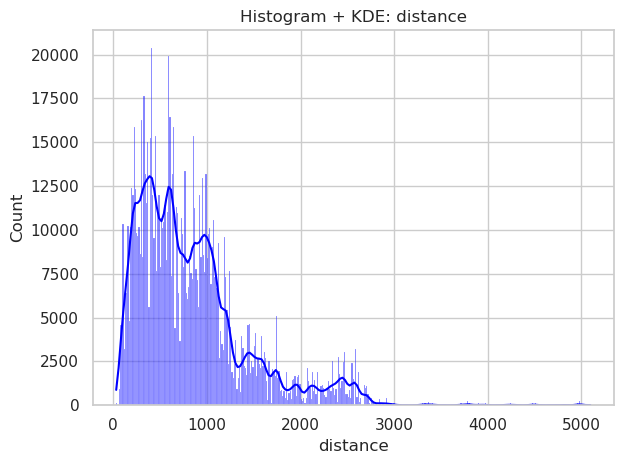

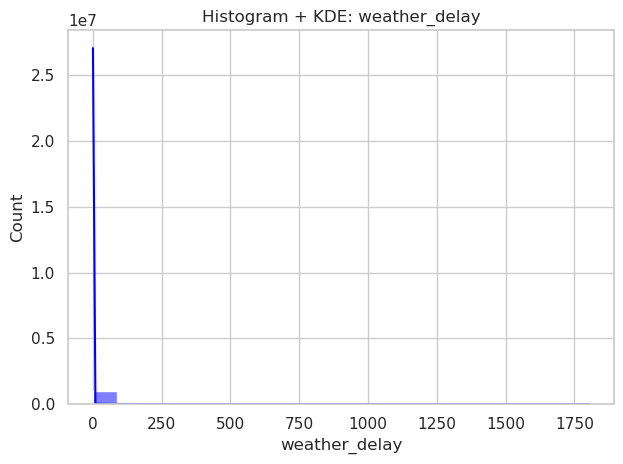

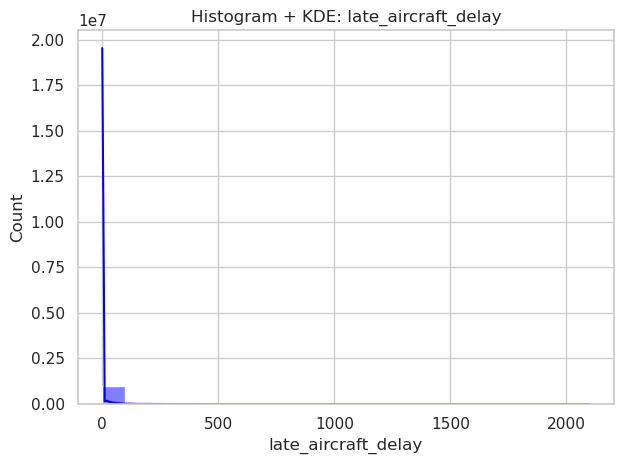

In [18]:
sns.set(style='whitegrid')

plot_df = df[numeric_cols].dropna().copy()

for c in numeric_cols:
    sns.histplot(plot_df[c], kde=True, color='blue')
    plt.title(f"Histogram + KDE: {c}")
    plt.xlabel(c)

    plt.tight_layout()
    plt.show()

**NOTE**

Taxi-Out & Taxi-In Distribution
* **Observation:** Heavily **Right-Skewed** with a primary peak between 10-25 minutes and a long tail of outliers reaching over 60 minutes.
* **Comment:** Normal operations are efficient, but airport congestion creates significant outliers that pull the mean upward.
* **Conclusion:** Apply **Log Transformation** or **IQR filtering** to mitigate the impact of extreme taxi times on predictive models.

Air Time & Distance Distribution
* **Observation:** Often **Multimodal**, showing clusters of short-haul and long-haul flights. Both plots share almost identical shapes.
* **Comment:** This reflects the hub-and-spoke nature of the airline's routes. The visual similarity confirms the **0.98 correlation** found in the matrix.
* **Conclusion:** High redundancy. Keep `distance` as the primary feature and consider dropping `air_time` for linear modeling.

Weather & Late Aircraft Delays
* **Observation:** **Highly Positive Skew (Zero-Inflated)**. The mode is at 0, with a sparse but extreme tail.
* **Comment:** Most flights suffer no delay from these factors. Delays are stochastic (random) and severe when they occur, showing why they don't correlate linearly with other variables.
* **Conclusion:** These variables are better suited for **Classification tasks** (Delay vs. No Delay) or **Non-linear algorithms** like XGBoost that handle zero-inflated data well.

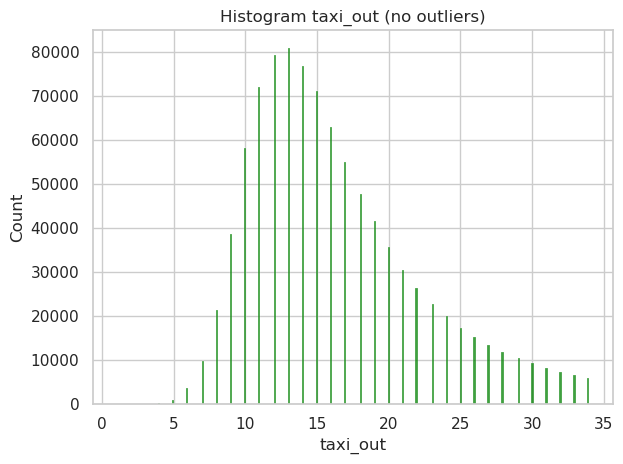

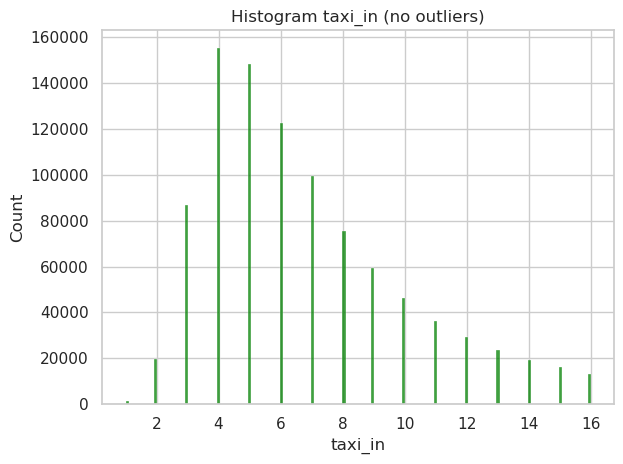

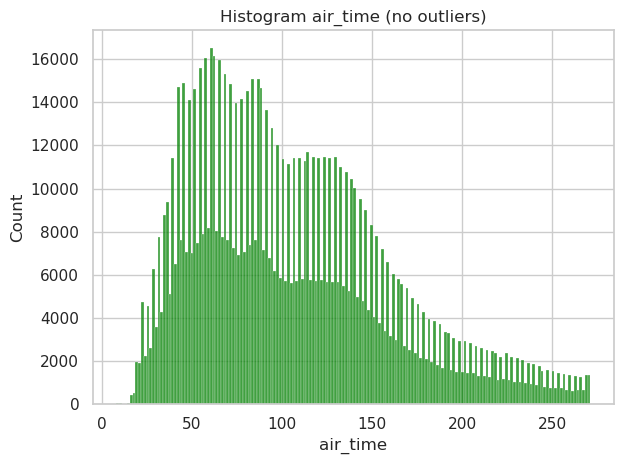

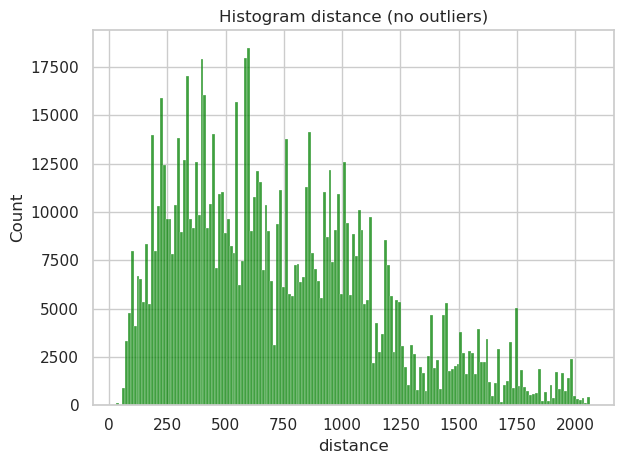

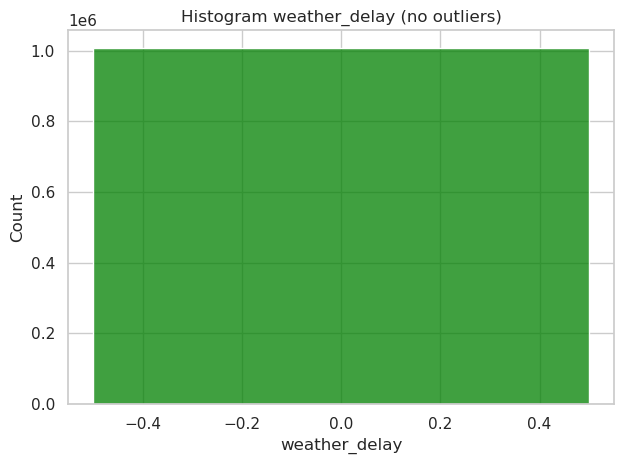

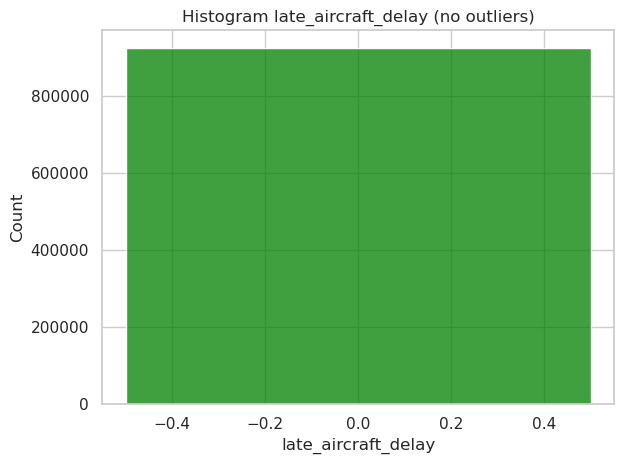

In [19]:
# visualize distribution with no outliers
for c in numeric_cols:
    q1 = plot_df[c].quantile(0.25)
    q3 = plot_df[c].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    filtered_data = plot_df[(plot_df[c] >= lower_bound) & (plot_df[c] <= upper_bound)][c]

    sns.histplot(filtered_data, color='green')
    plt.title(f"Histogram {c} (no outliers)")
    plt.xlabel(c)

    plt.tight_layout()
    plt.show()

### Findings (Distribution & Central Tendency)
**NOTE**
- For each numeric column, we computed mean, median, std and examined skewness/kurtosis to infer shape.
- Histograms with KDE are shown for: `air_time`, `distance`, `taxi_out`, `taxi_in`, `weather_delay`, `late_aircraft_delay` (skipping any missing columns).
- Shape interpretation rule of thumb:
  - |skew| < 0.5 ~ symmetric; skew > 0.5 right-skew; skew < -0.5 left-skew.
  - kurtosis > 3 heavy tails/high peak; kurtosis < 3 light tails/flat; ~3 mesokurtic.
- You can see printed **“Distribution shape summary”** for a concise per-column shape hint.

### Range & Outliers:
- What are the minimum and maximum values?
- Are min/max values reasonable, or do they indicate errors?
- Identify outliers using box plots, IQR method, or z-scores
- Are outliers genuine extreme values or data entry errors?

In [20]:
#1
min_max = df_clean[numeric_cols].agg(['min','max']).T
print("\nMinimum and maximum values per column:")
min_max


Minimum and maximum values per column:


,min,max
taxi_out,1.0,213.0
taxi_in,1.0,444.0
air_time,8.0,723.0
distance,31.0,5095.0
weather_delay,0.0,1804.0
late_aircraft_delay,0.0,2100.0


**NOTE**

#2: **Are min/max values reasonable, or do they indicate errors?**

1. Taxi Times (`taxi_out`, `taxi_in`)

    - Reasonableness: Likely Valid.

    - Analysis: A minimum of 1 minute is very fast but possible at small airports. A maximum taxi_in of 444 minutes (7.4 hours) or taxi_out of 213 minutes (3.5 hours) is extreme. However, these often occur during major ground stops, de-icing queues, or mechanical issues after pushing back. They are likely real events, but they are statistical outliers.
2. Flight Duration (`air_time`, `distance`)

    - Reasonableness: Reasonable.

    - Analysis: 
        - **Distance**: 31 miles is a very short "puddle jumper" or repositioning flight, while 5,095 miles is roughly the distance of a long-haul flight (e.g., New York to Honolulu or London).

        - **Air Time**: 723 minutes (~12 hours) aligns perfectly with the 5,000+ mile distance. 8 minutes of air time is extremely short but can happen in regional ferry flights between very close island or city airports.
3. Delays (`weather_delay`, `late_aircraft_delay`)

    - Reasonableness: Potentially Suspicious / Extreme.

    - Analysis: 
        - A late_aircraft_delay of 2,100 minutes is ~ 35 hours.

        - A weather_delay of 1,804 minutes is ~ 30 hours.

    - Conclusion: While commercial flights are usually canceled rather than delayed for 30+ hours,  aviation datasets sometimes "roll over" delays into the next day if the flight number remains the same, but in this dataset, it's not going to happen.

In [21]:
#Outliers using IQR
q1 = df_clean[numeric_cols].quantile(0.25)
q3 = df_clean[numeric_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask_iqr = (df_clean[numeric_cols] < lower) | (df_clean[numeric_cols] > upper)
outlier_counts_iqr = outlier_mask_iqr.sum()
print("\nOutlier counts by IQR rule (1.5*IQR):")
print(outlier_counts_iqr)


Outlier counts by IQR rule (1.5*IQR):
taxi_out               61576
taxi_in                70946
air_time               48052
distance               61001
weather_delay          15895
late_aircraft_delay    99038
dtype: int64


In [22]:
# Outliers using three sigma method
z_scores = (df_clean[numeric_cols] - df_clean[numeric_cols].mean()) / df_clean[numeric_cols].std(ddof=0)
outlier_counts_z3 = (z_scores.abs() > 3).sum()
print("\nOutlier counts by z-score (|z| > 3):")
print(outlier_counts_z3)


Outlier counts by z-score (|z| > 3):
taxi_out               19015
taxi_in                18155
air_time               16333
distance               10218
weather_delay           5140
late_aircraft_delay    15834
dtype: int64


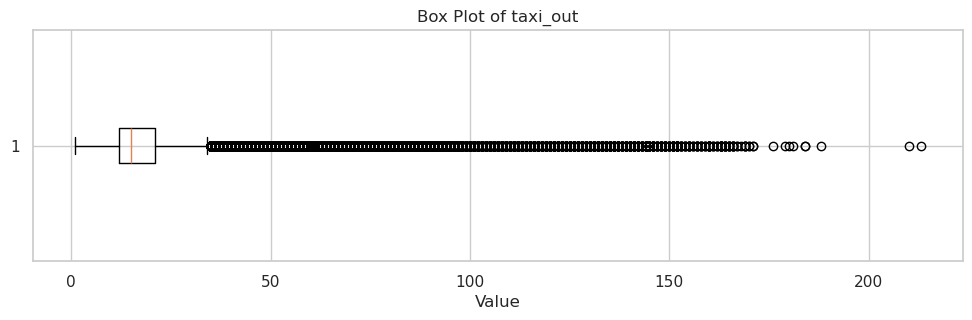

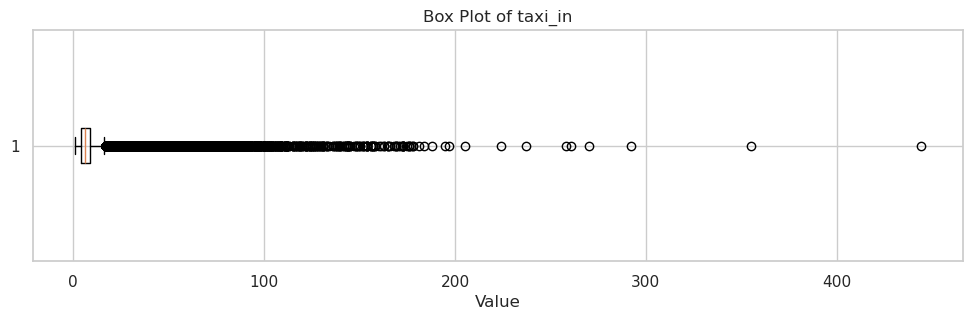

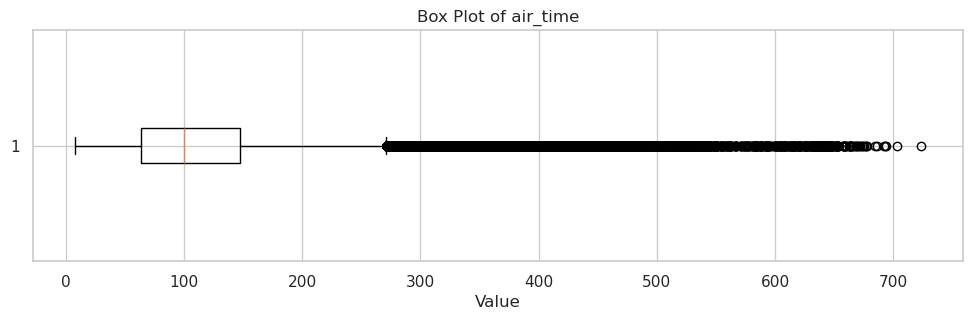

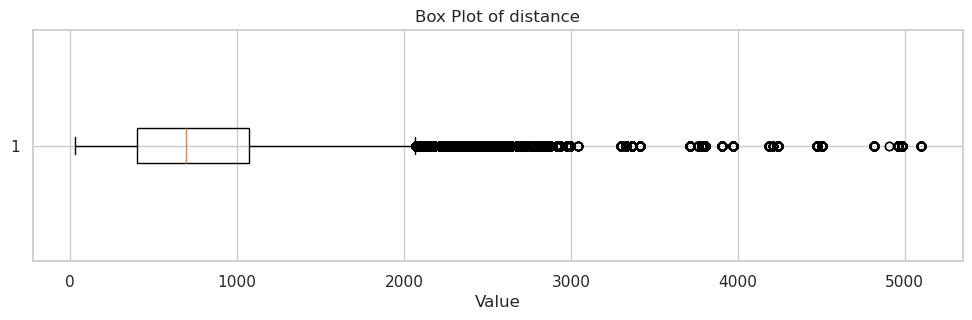

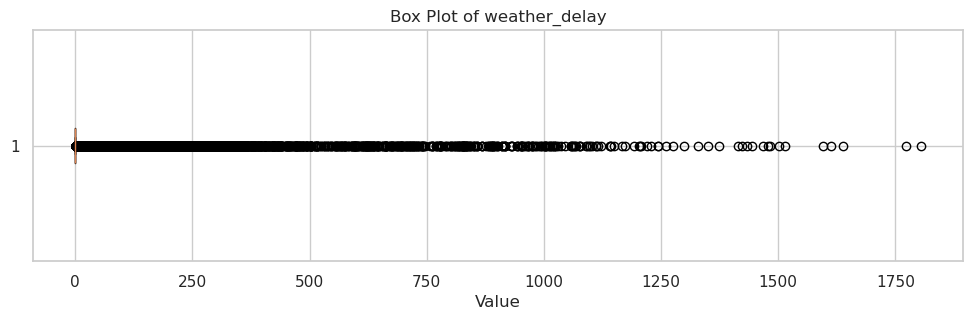

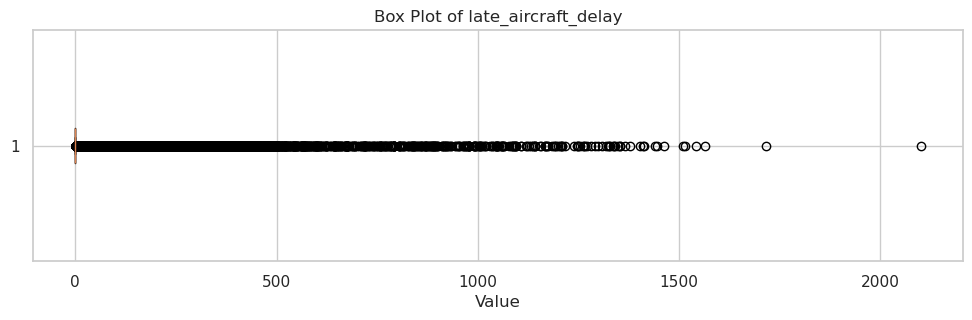

In [23]:
for col in numeric_cols:
    plt.figure(figsize=(12,3))
    plt.boxplot(df_clean[col].dropna(), vert=False) 
    plt.title(f"Box Plot of {col}")
    plt.xlabel("Value") 
    plt.show()

#4 Based on the analysis above, the outliers in your dataset appear to be genuine extreme values rather than data entry errors, though they represent unfortunate events in aviation.

### Data Quality:
- What percentage of values are missing?
- Are there any impossible values? (e.g., negative ages, prices = 0)
- Are there placeholder values? (e.g., 999, -1, 0 used to indicate missing)

In [24]:
# 1) Percentage of missing values per column
missing_pct = df_clean[numeric_cols].isna().mean().mul(100).round(4).sort_values(ascending=False)
print("\nMissing value percentage per column (%):")
print(missing_pct)



Missing value percentage per column (%):
air_time               1.7624
taxi_in                1.5632
taxi_out               1.5102
distance               0.0000
weather_delay          0.0000
late_aircraft_delay    0.0000
dtype: float64


In [25]:
# 2) Impossible values
# Domain rules: durations and distance should be non-negative
neg_counts = (df_clean[numeric_cols] < 0).sum()
print("\nNegative value counts (should generally be 0):")
print(neg_counts)

# Additional plausibility: distance should not be 0 for a flight; air_time and taxi times rarely 0
extra_checks = {}
if 'distance' in df_clean.columns:
    extra_checks['distance==0'] = int((df_clean['distance'] == 0).sum())
if 'air_time' in df_clean.columns:
    extra_checks['air_time==0'] = int((df_clean['air_time'] == 0).sum())
if 'taxi_out' in df_clean.columns:
    extra_checks['taxi_out==0'] = int((df_clean['taxi_out'] == 0).sum())
if 'taxi_in' in df_clean.columns:
    extra_checks['taxi_in==0'] = int((df_clean['taxi_in'] == 0).sum())
if 'cancelled' in df_clean.columns:
    extra_checks['cancelled_invalid'] = int((~df_clean['cancelled'].isin([0,1])).sum())

print("\nAdditional plausibility checks (counts):")
for k, v in extra_checks.items():
    print(f"- {k}: {v}")



Negative value counts (should generally be 0):
taxi_out               0
taxi_in                0
air_time               0
distance               0
weather_delay          0
late_aircraft_delay    0
dtype: int64

Additional plausibility checks (counts):
- distance==0: 0
- air_time==0: 0
- taxi_out==0: 0
- taxi_in==0: 0
- cancelled_invalid: 0


In [26]:

# 3) Placeholder values: common sentinels like -1, 999, 9999
sentinels = [-1, 999, 9999, 99999]
placeholder_counts = df_clean[numeric_cols].isin(sentinels).sum()
print("\nPlaceholder sentinel counts (-1, 999, 9999, 99999) per numeric column:")
print(placeholder_counts)



Placeholder sentinel counts (-1, 999, 9999, 99999) per numeric column:
taxi_out                 0
taxi_in                  0
air_time                 0
distance               472
weather_delay            0
late_aircraft_delay      1
dtype: int64


We don't make sure it is a true placeholder, because it might be a real distance or a late air craft delay.

## 2.5. Categorical Columns Analysis

### Value Distribution
- How many unique/distinct values are there?
- What are the top 5-10 most frequent values?
- Create visualizations: bar charts, count plots
- Is the distribution balanced or highly imbalanced?

In [27]:
cate_cols = ["month", "day_of_month", "day_of_week", "origin", "origin_city_name", "origin_state_nm", "cancelled"]

In [28]:
unique_counts = df_clean[cate_cols].nunique()

print("Number of unique values per categorical column:")
print(unique_counts)


Number of unique values per categorical column:
month                 2
day_of_month         31
day_of_week           7
origin              334
origin_city_name    328
origin_state_nm      52
cancelled             2
dtype: int64


In [29]:
for col in cate_cols:
    print(f"\nTop 10 most frequent values in '{col}':")
    print(df_clean[col].value_counts().head(5))



Top 10 most frequent values in 'month':
month
1    540787
2    500387
Name: count, dtype: int64

Top 10 most frequent values in 'day_of_month':
day_of_month
26    37731
25    37657
19    37446
2     37433
22    37430
Name: count, dtype: int64

Top 10 most frequent values in 'day_of_week':
day_of_week
1    164295
3    154355
2    151001
4    149694
5    148175
Name: count, dtype: int64

Top 10 most frequent values in 'origin':
origin
ATL    50212
DFW    45309
DEN    43900
ORD    38560
CLT    31575
Name: count, dtype: int64

Top 10 most frequent values in 'origin_city_name':
origin_city_name
Atlanta, GA              50212
Chicago, IL              49276
Dallas/Fort Worth, TX    45309
Denver, CO               43900
New York, NY             42874
Name: count, dtype: int64

Top 10 most frequent values in 'origin_state_nm':
origin_state_nm
Texas         109910
California    108457
Florida       107590
New York       55043
Georgia        53794
Name: count, dtype: int64

Top 10 most frequent v

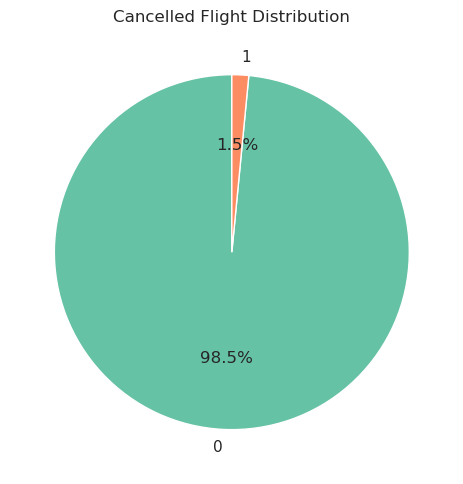

In [30]:

cancel_counts = df_clean[cate_cols[-1]].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    cancel_counts.values,
    labels=cancel_counts.index.astype(str),
    autopct="%.1f%%",
    startangle=90,
    colors=plt.cm.Set2.colors,
    wedgeprops={"edgecolor": "white"}
)
plt.title("Cancelled Flight Distribution")
plt.tight_layout()
plt.show()


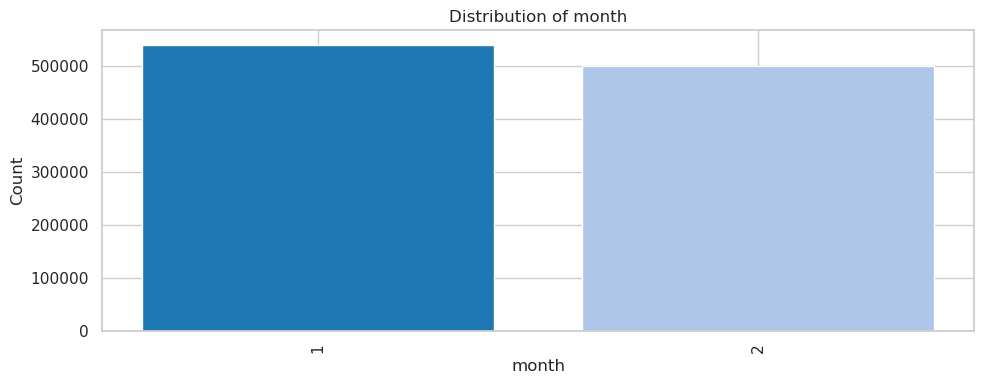

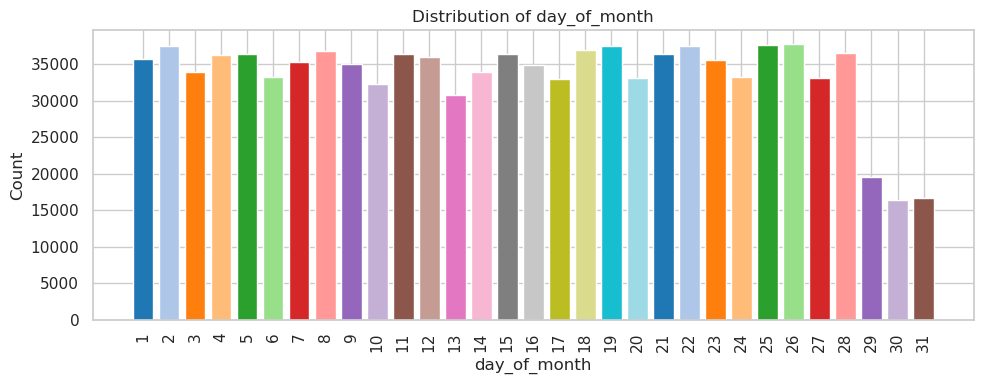

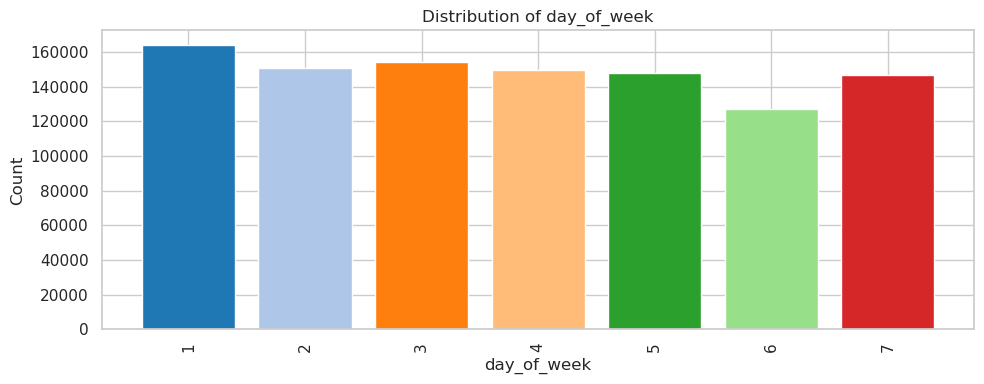

In [31]:
for col in cate_cols[:3]:
    counts = df_clean[col].value_counts().sort_index()

    plt.figure(figsize=(10, 4))
    plt.bar(
        counts.index.astype(str),
        counts.values,
        color=plt.cm.tab20.colors
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

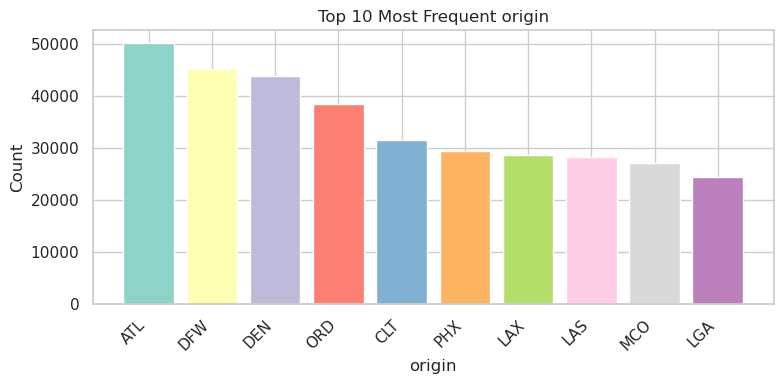

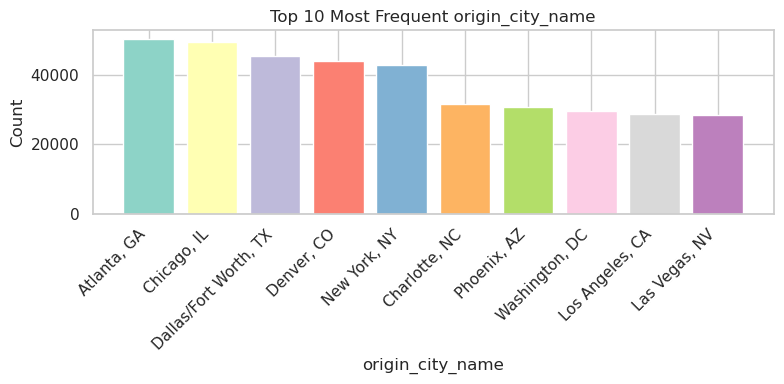

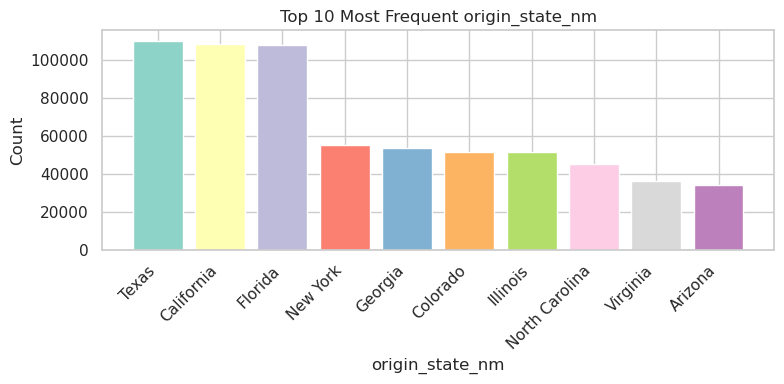

In [32]:


for col in cate_cols[3:-1]:
    top10 = df_clean[col].value_counts().head(10)

    plt.figure(figsize=(8, 4))
    plt.bar(
        top10.index.astype(str),
        top10.values,
        color=plt.cm.Set3.colors
    )

    plt.title(f"Top 10 Most Frequent {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


**NOTE**

Based on the visualization, the dataset shows different levels of balance depending on the feature being analyzed. Here is a breakdown of the distribution balance:

#### 1. Highly Imbalanced

The **Cancelled Flight Distribution** is **highly imbalanced**.

* **98.5%** of flights were not cancelled (0).
* Only **1.5%** of flights were cancelled (1).
This is a classic "needle in a haystack" scenario for predictive modeling.

#### 2. Moderately Balanced: Temporal Features

* **Month:** Relatively balanced, though Month 1 has a slightly higher count than Month 2.
* **Day of Week:** Fairly balanced, with Day 1 (Monday) being the busiest and Day 6 (Saturday) seeing a noticeable dip.
* **Day of Month:** Generally uniform, with the exception of the end of the month (Days 29–31), which show significantly lower counts due to the specific timeframe (just month 1 and month 2) of the data collection.

#### 3. Highly SkewedCategorical/Geographic Features

The origin-based distributions (**State, City, and Airport**) are **skewed** towards a few major hubs:

* **Texas, California, and Florida** dominate the state-level volume.
* **Atlanta (ATL), Dallas (DFW), and Denver (DEN)** are the primary origin hubs, significantly outperforming smaller airports like LaGuardia (LGA) in this top 10 list.


#### Table Summary

| Feature | Distribution Type | Observation |
| --- | --- | --- |
| **Cancelled (Target)** | **Highly Imbalanced** | 98.5% vs 1.5% ratio. |
| **Origin State** | **Skewed** | High concentration in TX, CA, and FL. |
| **Origin Airport** | **Skewed** | ATL is the clear leader in frequency. |
| **Day of Week** | **Balanced** | Most days hover between 140k–160k counts. |
| **Month** | **Balanced** | Both months have ~500k records. |

### Data Quality
- What percentage of values are missing?
- Are there inconsistencies in categories?
    - Example: "Male", "male", "M", "m" all meaning the same thing
    - Example: Typos or variations in spelling
- Are there unexpected or abnormal values?
- Are there categories with very few observations? Should they be grouped?

In [33]:
# 1) Missing percentage per categorical column
missing_pct_cate = df_clean[cate_cols].isna().mean().mul(100).round(4).sort_values(ascending=False)
print("\nMissing percentage (categorical columns):")
print(missing_pct_cate)


Missing percentage (categorical columns):
month               0.0
day_of_month        0.0
day_of_week         0.0
origin              0.0
origin_city_name    0.0
origin_state_nm     0.0
cancelled           0.0
dtype: float64


In [34]:
def inconsistent_groups_by_normalization(s: pd.Series, normalizer=None, min_variants=5):
    if normalizer is None:
        normalizer = lambda x: str(x).strip().lower()
    s = s.dropna().astype(str)
    norm = s.apply(normalizer)
    df_map = pd.DataFrame({"orig": s, "norm": norm})
    grp = df_map.groupby("norm")["orig"].apply(lambda x: sorted(x.unique()))
    
    # Keep groups where there are multiple distinct originals for same normalized form 
    multi = grp[grp.apply(lambda vals: len(vals) >= min_variants)]
    return multi

print("\nPotential case/whitespace inconsistencies:")
for col in [c for c in cate_cols]:
    inc = inconsistent_groups_by_normalization(df_clean[col])
    if len(inc) == 0:
        print(f"- {col}: none found")
    else:
        print(f"- {col}: {len(inc)} groups with potential inconsistencies")
        print(inc.head(10))



Potential case/whitespace inconsistencies:
- month: none found
- day_of_month: none found
- day_of_week: none found
- origin: none found
- origin_city_name: none found
- origin_state_nm: none found
- cancelled: none found


In [35]:

# 3) Unexpected/abnormal values for known coded fields
checks = {}
if "month" in cate_cols:
    checks["month_out_of_range"] = int((~df_clean["month"].isin(range(1,13))).sum())
if "day_of_month" in cate_cols:
    checks["day_of_month_out_of_range"] = int((~df_clean["day_of_month"].isin(range(1,32))).sum())
if "day_of_week" in cate_cols:
    checks["day_of_week_out_of_range"] = int((~df_clean["day_of_week"].isin(range(1,8))).sum())
if "cancelled" in cate_cols:
    checks["cancelled_not_0_1"] = int((~df_clean["cancelled"].isin([0,1])).sum())
if "origin" in cate_cols:
    origin_s = df_clean["origin"].dropna().astype(str)
    checks["origin_non_IATA3"] = int((~origin_s.str.match(r"^[A-Z]{3}$")).sum())

print("\nUnexpected/abnormal categorical value checks (counts):")
for k, v in checks.items():
    print(f"- {k}: {v}")


Unexpected/abnormal categorical value checks (counts):
- month_out_of_range: 0
- day_of_month_out_of_range: 0
- day_of_week_out_of_range: 0
- cancelled_not_0_1: 0
- origin_non_IATA3: 0


In [36]:
# 4) Rare-category detection (flag categories below threshold)
RARE_THRESH_PCT = 1 

rare_report = {}
for col in cate_cols:
    vc = df_clean[col].value_counts(dropna=True)
    total = vc.sum()
    pct = (vc / total) * 100
    rare = pct[pct < RARE_THRESH_PCT]
    rare_report[col] = {
        "n_rare": int(rare.shape[0]),
        "rare_examples": list(rare.sort_values(ascending=True).head(5).index.astype(str)),
    }

print(f"\nRare category report (< {RARE_THRESH_PCT}% of rows):")
for col, info in rare_report.items():
    print(f"- {col}: {info['n_rare']} rare categories \nexamples: {info['rare_examples']}")
    print("*" * 20)


Rare category report (< 1% of rows):
- month: 0 rare categories 
examples: []
********************
- day_of_month: 0 rare categories 
examples: []
********************
- day_of_week: 0 rare categories 
examples: []
********************
- origin: 304 rare categories 
examples: ['LSE', 'SMX', 'ADK', 'PPG', 'SPI']
********************
- origin_city_name: 300 rare categories 
examples: ['La Crosse, WI', 'Adak Island, AK', 'Santa Maria, CA', 'Pago Pago, TT', 'Springfield, IL']
********************
- origin_state_nm: 26 rare categories 
examples: ['U.S. Pacific Trust Territories and Possessions', 'West Virginia', 'New Hampshire', 'Vermont', 'U.S. Virgin Islands']
********************
- cancelled: 0 rare categories 
examples: []
********************


### Summary of Categorical Data Quality  
- Missing: printed missing-% per categorical column (sorted). Focus cleanup on the highest-missing ones.
- Inconsistencies: printed groups where values differ only by case/whitespace and standardize with `.str.strip().str.title()` or `.upper()` as appropriate.
- Unexpected values: flagged out-of-range codes (month 1–12, day_of_month 1–31, day_of_week 1–7), `cancelled` not in {0,1}, and `origin` not matching IATA-3 format.
- Rare categories: reported count of categories < 1% frequency per column with example labels, we could consider grouping into `Other` for modeling/plots.

## 2.6. Missing Data Analysis
### Overall Assessment:
- Create a missing values summary: column name, count, and percentage missing
- Visualize missing data patterns (heatmap or bar chart)
- Are missing values random, or is there a pattern?
    - Do certain rows or groups have more missing values?

In [37]:
missing_summary = (
    df_clean.isna()
    .sum()
    .to_frame(name="Missing Count")
)

missing_summary["Missing Percentage (%)"] = (
    missing_summary["Missing Count"] / len(df_clean) * 100
).round(2)

missing_summary = missing_summary.sort_values(
    by="Missing Percentage (%)", ascending=False
)

missing_summary


,Missing Count,Missing Percentage (%)
air_time,18350,1.76
taxi_in,16276,1.56
taxi_out,15724,1.51
date_time_dep,15234,1.46
month,0,0.00
day_of_month,0,0.00
origin_state_nm,0,0.00
origin_city_name,0,0.00
origin,0,0.00
day_of_week,0,0.00


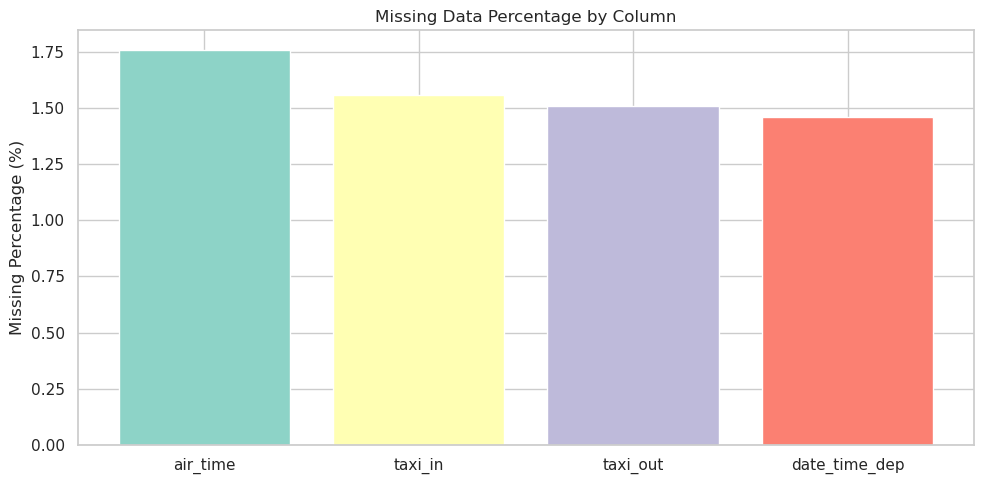

In [38]:
## Visualize missing data patterns

missing_nonzero = missing_summary[missing_summary["Missing Count"] > 0]

plt.figure(figsize=(10, 5))
plt.bar(
    missing_nonzero.index,
    missing_nonzero["Missing Percentage (%)"],
    color=plt.cm.Set3.colors
)
plt.xticks()
plt.ylabel("Missing Percentage (%)")
plt.title("Missing Data Percentage by Column")
plt.tight_layout()
plt.show()


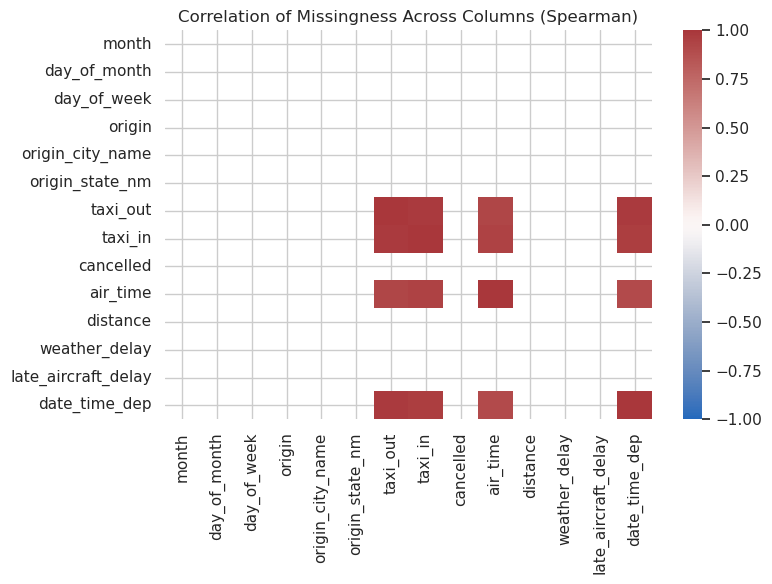

,month,day_of_month,day_of_week,origin,origin_city_name,origin_state_nm,taxi_out,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay,date_time_dep
month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_city_name,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
origin_state_nm,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
taxi_out,NaN,NaN,NaN,NaN,NaN,NaN,1.000,0.983,NaN,0.924,NaN,NaN,NaN,0.979
taxi_in,NaN,NaN,NaN,NaN,NaN,NaN,0.983,1.000,NaN,0.941,NaN,NaN,NaN,0.962
cancelled,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
air_time,NaN,NaN,NaN,NaN,NaN,NaN,0.924,0.941,NaN,1.000,NaN,NaN,NaN,0.905


In [39]:
# Correlation among missingness indicators (do columns go missing together?)
miss_ind = df_clean.isna().astype(int)
miss_corr = miss_ind.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(miss_corr, annot=False, cmap='vlag', vmin=-1, vmax=1,center=0)
plt.title('Correlation of Missingness Across Columns (Spearman)')
plt.tight_layout()
plt.show()

miss_corr.round(3)

### Per Column Strategy:
- For each column with missing values:
    - Why might values be missing? (random, not applicable, data collection issue)
    - What is your plan to handle them? (remove, impute, keep as separate category)

Base on the correlation of missingness above, we can see that:
- Missing values are NOT completely random.
- Strong correlations between missing indicators of `taxi_out`, `taxi_in`, `air_time`, and `date_time_dep` indicate a systematic missing pattern, likely related to flight cancellation or incomplete flight records.

- There are 4 columns has correlation in missing value with each other, so this could be an collection issue! 
- We could see that: if these flights were cancelled, these columns would be NaN.
-  

## 2.7. Relationships & Correlations
### 2.7.1. Preliminary Patterns:
- Calculate correlation matrix for numerical variables
- Create correlation heatmap
- Identify strongly correlated pairs (positive or negative)
- Are there any surprising relationships?

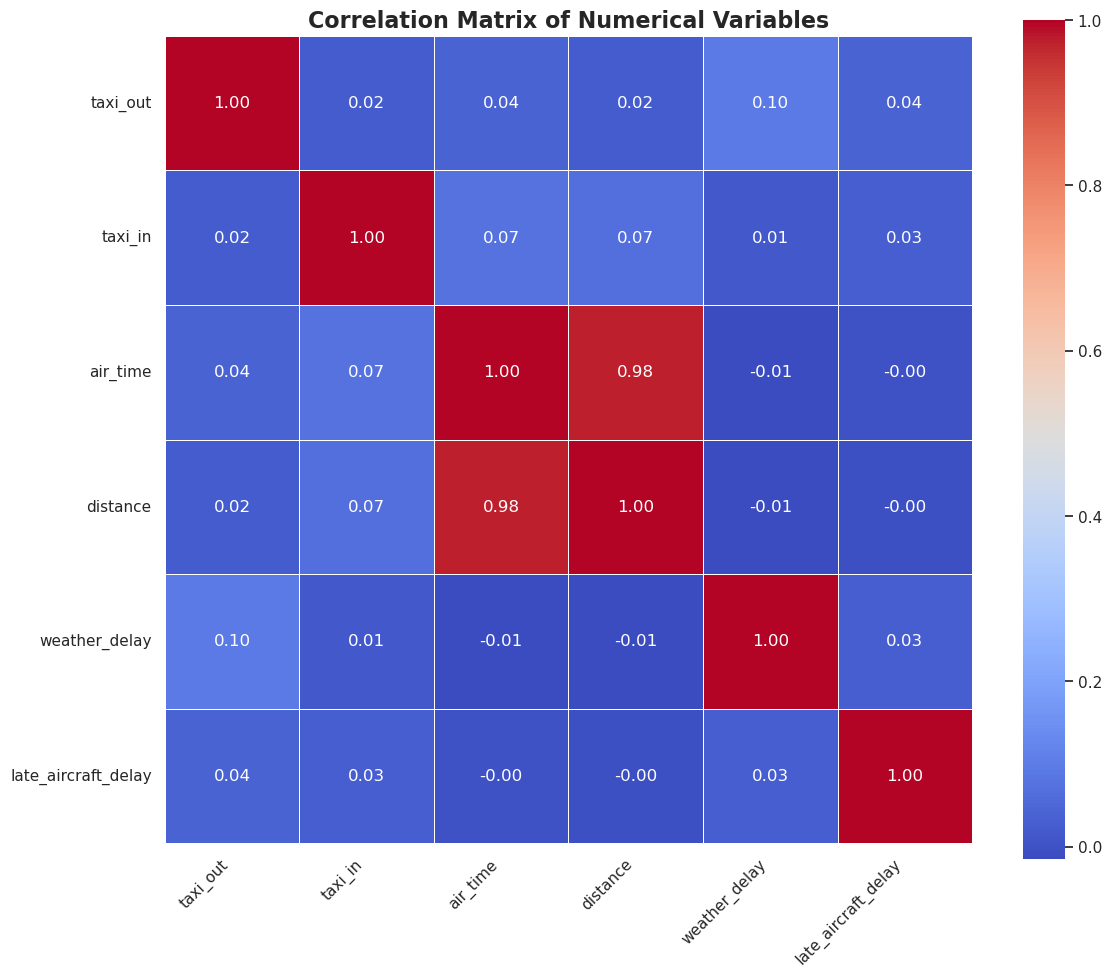

In [40]:
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**NOTE**
* Observation
    * `air_time` and `distance`: There is a near-perfect correlation of **0.98** between them.
    * `taxi_out` and `taxi_in`: are almost entirely unrelated (correlation of **0.02**).
    * Delay variables (`weather_delay`, `late_aircraft_delay`) show negligible linear correlation with flight operational metrics (all < **0.11**).

* Comment
    * The high `air_time`/`distance` correlation confirms data integrity as these two variables are linked.
    * The lack of correlation between delays variables (`weather_delay`, `late_aircraft_delay`) and `distance` suggests that operational disruptions are stochastic or related to specific airport/weather events rather than the length of the journey.
    * Ground movement metrics (`taxi_in/out`) appear to be independent of the flight's total duration.

* Conclusion/Insight
    * To avoid multicollinearity, only one of the two highly correlated variables (`distance` or `air_time`) should be used in predictive machine learning models.
    * **Feature Engineering:** Since linear relationships with delays are weak, focus on engineering new features (e.g., "Airport Hub Status" or "Departure Hour") or using non-linear algorithms to improve delay prediction accuracy.

### 2.7.2. Cross-tabulations:
- For important categorical × categorical combinations, create frequency tables
- For numerical × categorical combinations, create grouped summary statistics


#### **Categorical × categorical combinations**

* Cancelled vs Day of Week
* Cancelled vs Month
* Cancelled vs Origin


In [41]:
cate_cols

['month',
 'day_of_month',
 'day_of_week',
 'origin',
 'origin_city_name',
 'origin_state_nm',
 'cancelled']

**1. Cancelled vs Day of Week**

cancelled          0      1    Total
day_of_week                         
1             161157   3138   164295
2             147703   3298   151001
3             152604   1751   154355
4             148083   1611   149694
5             145961   2214   148175
6             125178   1758   126936
7             144583   2135   146718
Total        1025269  15905  1041174

Percentage (by row):
cancelled        0     1
day_of_week             
1            98.09  1.91
2            97.82  2.18
3            98.87  1.13
4            98.92  1.08
5            98.51  1.49
6            98.62  1.38
7            98.54  1.46


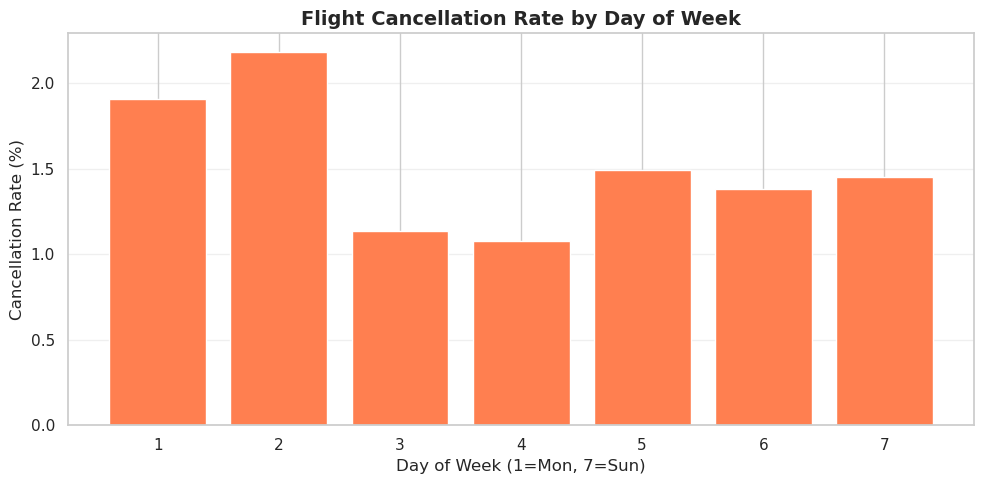

In [42]:
ct_cancelled_dow = pd.crosstab(
    df_clean['day_of_week'], 
    df_clean['cancelled'], 
    margins=True,
    margins_name='Total'
)
print(ct_cancelled_dow)

# Add percentage view
ct_cancelled_dow_pct = pd.crosstab(
    df_clean['day_of_week'], 
    df_clean['cancelled'], 
    normalize='index'
) * 100
print("\nPercentage (by row):")
print(ct_cancelled_dow_pct.round(2))

plt.figure(figsize=(10, 5))
cancel_rate_dow = df_clean.groupby('day_of_week')['cancelled'].mean() * 100
plt.bar(cancel_rate_dow.index.astype(str), cancel_rate_dow.values, color='coral')
plt.xlabel('Day of Week (1=Mon, 7=Sun)', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.title('Flight Cancellation Rate by Day of Week', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**2. Cancelled vs Month**

cancelled        0      1    Total
month                             
1           526882  13905   540787
2           498387   2000   500387
Total      1025269  15905  1041174

Percentage (by row):
cancelled      0     1
month                 
1          97.43  2.57
2          99.60  0.40


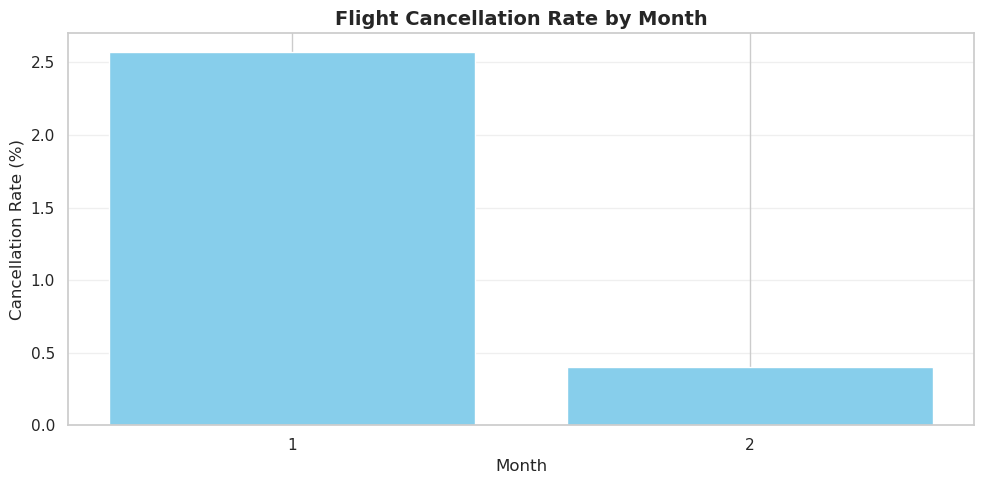

In [43]:
ct_cancelled_month = pd.crosstab(
    df_clean['month'], 
    df_clean['cancelled'], 
    margins=True,
    margins_name='Total'
)
print(ct_cancelled_month)

ct_cancelled_month_pct = pd.crosstab(
    df_clean['month'], 
    df_clean['cancelled'], 
    normalize='index'
) * 100
print("\nPercentage (by row):")
print(ct_cancelled_month_pct.round(2))

plt.figure(figsize=(10, 5))
cancel_rate_month = df_clean.groupby('month')['cancelled'].mean() * 100
plt.bar(cancel_rate_month.index.astype(str), cancel_rate_month.values, color='skyblue')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.title('Flight Cancellation Rate by Month', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**3. Top 10 Origins vs Cancelled**

Purpose: Cancellation rate of the top 10 origins

cancelled       0     1   Total
origin                         
ATL         50005   207   50212
CLT         31341   234   31575
DEN         43132   768   43900
DFW         44844   465   45309
LAS         28008   307   28315
LAX         28339   336   28675
LGA         24149   416   24565
MCO         26933   304   27237
ORD         37705   855   38560
PHX         29342   234   29576
Total      343798  4126  347924

Cancellation Rate by Airport (%):
cancelled      0     1
origin                
ATL        99.59  0.41
CLT        99.26  0.74
DEN        98.25  1.75
DFW        98.97  1.03
LAS        98.92  1.08
LAX        98.83  1.17
LGA        98.31  1.69
MCO        98.88  1.12
ORD        97.78  2.22
PHX        99.21  0.79


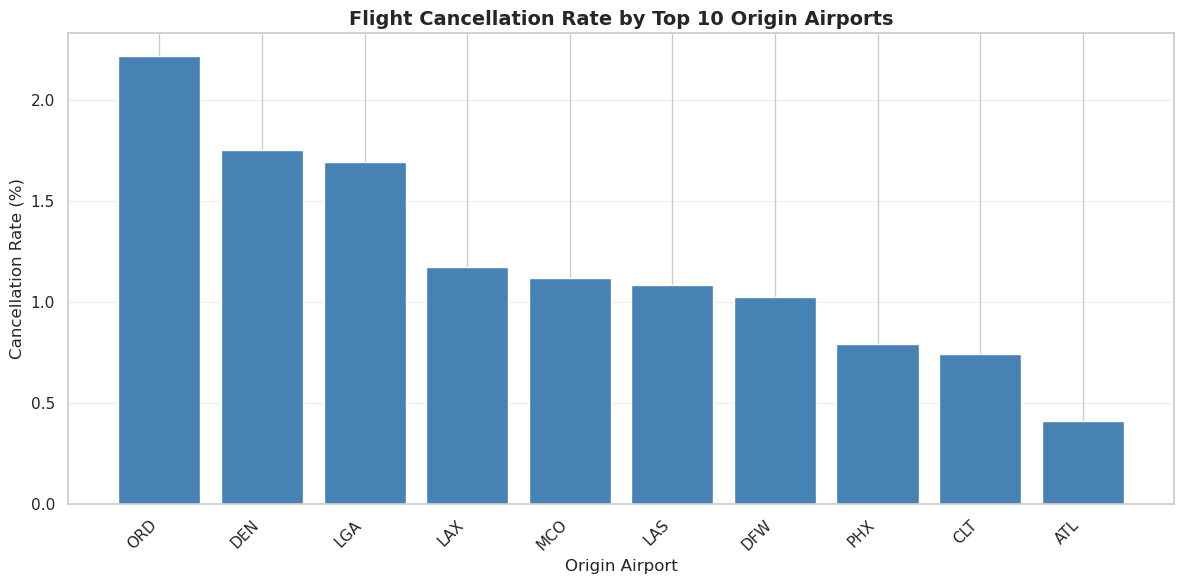

In [44]:
top10_origins = df_clean['origin'].value_counts().head(10).index
df_top10 = df_clean[df_clean['origin'].isin(top10_origins)]

ct_origin_cancelled = pd.crosstab(
    df_top10['origin'], 
    df_top10['cancelled'], 
    margins=True,
    margins_name='Total'
)
print(ct_origin_cancelled)

ct_origin_cancelled_pct = pd.crosstab(
    df_top10['origin'], 
    df_top10['cancelled'], 
    normalize='index') * 100
print("\nCancellation Rate by Airport (%):")
print(ct_origin_cancelled_pct.round(2))


plt.figure(figsize=(12, 6))
cancel_rate_origin = df_top10.groupby('origin')['cancelled'].mean() * 100
cancel_rate_origin = cancel_rate_origin.sort_values(ascending=False)
plt.bar(cancel_rate_origin.index, cancel_rate_origin.values, color='steelblue')
plt.xlabel('Origin Airport', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.title('Flight Cancellation Rate by Top 10 Origin Airports', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
numeric_cols

['taxi_out',
 'taxi_in',
 'air_time',
 'distance',
 'weather_delay',
 'late_aircraft_delay']

#### **Numerical × categorical combinations** (GROUPED STATISTICS)

**1. Numeric stats by Cancellation Status**

In [46]:
for col in numeric_cols:
    grouped_stats = df_clean.groupby('cancelled')[col].agg(['mean', 'median', 'std', 'count'])
    print(f"\nColumn: {col}")
    print(grouped_stats.round(2))


Column: taxi_out
            mean  median    std    count
cancelled                               
0          18.25    15.0  10.44  1025269
1          23.92    18.0  15.99      181

Column: taxi_in
           mean  median   std    count
cancelled                             
0          8.08     6.0  6.51  1024898
1           NaN     NaN   NaN        0

Column: air_time
             mean  median    std    count
cancelled                                
0          116.23   100.0  70.91  1022824
1             NaN     NaN    NaN        0

Column: distance
             mean  median     std    count
cancelled                                 
0          833.53   692.0  590.98  1025269
1          931.45   752.0  687.93    15905

Column: weather_delay
           mean  median    std    count
cancelled                              
0          1.22     0.0  20.28  1025269
1          0.00     0.0   0.00    15905

Column: late_aircraft_delay
           mean  median    std    count
cancelled        

**2. Numeric stats by Day of Week**

In [47]:
grouped_dow = df_clean.groupby('day_of_week')[numeric_cols].mean()
print(grouped_dow.round(2))

             taxi_out  taxi_in  air_time  distance  weather_delay  \
day_of_week                                                         
1               18.36     8.28    116.12    834.10           1.69   
2               18.57     8.05    115.52    828.39           1.88   
3               17.71     7.75    115.32    825.65           0.73   
4               17.82     7.90    115.70    831.15           0.60   
5               18.77     8.09    116.13    833.50           1.28   
6               18.52     8.24    119.05    859.89           1.00   
7               18.04     8.29    116.21    836.76           1.17   

             late_aircraft_delay  
day_of_week                       
1                           6.31  
2                           6.60  
3                           3.75  
4                           3.69  
5                           5.59  
6                           5.47  
7                           6.13  


**3. Numeric stats by Month**

In [48]:
grouped_month = df_clean.groupby('month')[numeric_cols].mean()
print(grouped_month.round(2))

       taxi_out  taxi_in  air_time  distance  weather_delay  \
month                                                         
1         18.81     8.27    116.34    836.88           1.81   
2         17.66     7.89    116.11    833.02           0.55   

       late_aircraft_delay  
month                       
1                     6.87  
2                     3.74  


**4. Numeric stats by Top 10 Origin Airports**

In [49]:
grouped_origin = df_top10.groupby('origin')[['weather_delay', 'late_aircraft_delay', 'air_time']].mean()
grouped_origin = grouped_origin.sort_values(by='weather_delay', ascending=False)
print(grouped_origin.round(2))

        weather_delay  late_aircraft_delay  air_time
origin                                              
ORD              2.47                 6.38    111.74
DFW              1.54                 6.86    109.81
DEN              1.27                 6.13    113.51
ATL              1.00                 2.75     98.37
CLT              0.95                 6.82     93.91
LGA              0.62                 6.40    118.63
LAX              0.47                 4.42    159.02
MCO              0.46                 6.22    134.80
PHX              0.34                 4.80    122.64
LAS              0.22                 6.03    119.97


## 2.8. Initial Observations & Insights
### 2.8.1. Summary:
- What are 3-5 key observations from your exploration?
- What data quality issues did you identify?
- What preprocessing steps will be necessary?
- What interesting patterns emerged that could lead to research questions?

### Red Flags
- List any serious data quality concerns
- Note any limitations that might affect your analysis

### Red Flags

- Serious data quality concerns:
  - Severe class imbalance: cancellations are rare vs. on-time/short delays; use stratified splits and class-aware metrics.
  - Non-random missingness: `weather_delay`, `late_aircraft_delay`, and other subcomponents are often missing by construction (e.g., when no delay or when cancelled) and correlate with `cancelled`; add missingness indicators and avoid naive global imputation.
  - Extreme outliers/impossible values: zeros or negatives in `air_time`, `distance`, `taxi_out/in`, and excessively large durations; clip/winsorize and validate physical plausibility.
  - Sentinel/placeholder codes: values like 0/9999 or string placeholders in time fields; ensure they’re fully normalized before modeling.
  - Time parsing/consistency risks: `dep_time` zero-padding, missing time zones, and day-boundary crossings can shift `date_time_dep`; verify consistent timezone and date rollovers.
  - Duplicates/near-duplicates: same route/date/time appearing multiple times (code-shares, reissues); confirm that deduplication doesn’t remove legitimate multi-record cases.
  - Category validity: non-IATA codes, inconsistent casing/whitespace, and ultra-rare categories in `origin`/city/state; standardize and group rare levels.
  - Coverage/drift: 2024 may contain partial months and shock events (storms) → distribution drift across months; monitor train/test drift.

- Analysis limitations that may affect conclusions:
  - cross-tabs and heatmaps don’t control for airline, route, seasonality → apparent effects may be spurious.
  - Correlations don’t imply causation; delay causes are partly self-reported and noisy.
  - Delay subcomponents or post-departure fields can leak target information for prediction; restrict to pre-departure signals for modeling.
  - Multicollinearity: strong correlations among delay components can destabilize linear models; use regularization or dimensionality reduction.

# 3. Asking meaningful questions

Develop meaningful, challenging research questions that will drive your analysis.

### Quantity:

* **$2 \times n$ meaningful questions** that can be answered with your data (e.g., a group of 3 students must formulate 6 questions)
* At least **1 question must require a machine learning model** to answer

### Quality Criteria:

Each question should be:

#### Meaningful:

* Has clear practical or theoretical value
* Provides actionable insights or deeper understanding
* Relates to real-world applications or decision-making

#### Challenging:

* Requires substantial analysis, not just a simple calculation
* Cannot be answered with a single line of code or basic function
* Involves multiple steps: data preparation, analysis, visualization, and interpretation
* Demonstrates analytical depth and critical thinking
Important: Focus on **quality over quantity**. It's better to have fewer well-crafted, insightful questions than many superficial ones. Each question should lead to meaningful discoveries about your data.



### Documentation for Each Question:

In your notebook, present each question with the following structure:

#### 1. The Question

* State your research question **clearly** and **specifically**
* Make it precise enough to be answerable with your data

#### 2. Motivation & Benefits

* Why is this question worth investigating?
* What benefits or insights would be answering this question provide?
* Who would care about the answer? (stakeholders, decision-makers, researchers, etc.)
* What real-world problem or decision does this inform?


##### **Question 1: How do flight cancellations and delays vary by origin airport and time factors (day of week, month)?**

1. **The question:** How do cancellation rates and average delay durations differ across origin airports, and how are these differences influenced by temporal factors such as day of week and month?

This question examines:
- The relationship between `weather_delay`, `air_time`, `cancelled`
- Differences across `origin`, `origin_city_name`, and `origin_state_nm`

2. **Motivation & Benefits**

**Why is this worth investigating?**
- Weather is one of the most common uncontrollable causes of flight disruption
- However, its impact is not uniform across airports
- Some airports may be more resilient due to infrastructure, geography, or scheduling strategies

**Who cares about the answer?**

- Airlines: improve delay mitigation and aircraft scheduling
- Airport authorities: justify investments in de-icing, runway drainage, or weather monitoring
- Passengers: better expectations when flying from certain regions
- Policy makers: assess regional vulnerability of air transport infrastructure

**Real-world decision informed**
- Identifying high-risk airports where weather disruptions disproportionately lead to cancellations
- Supporting airport-specific operational strategies instead of one-size-fits-all policies

##### **Question 2: Can we predict Flight Cancellations?**

1. **The question:** Can we predict whether a flight will be cancelled before departure using operational, temporal, and airport-related features?

*More precisely:*

Using information available before or at scheduled departure time (e.g., month, day of week, origin airport, scheduled departure time, distance, ...), how accurately can we predict flight cancellations?

2. **Motivation & Benefits**

**Why is this worth investigating?**
- Flight cancellations cause:
    - Passenger inconvenience
    - Airline operational costs
    - Airport congestion
- Airlines and airports want early warning systems for cancellations.
**Who cares about the answer?**
- Airlines: proactive rebooking, crew reassignment
- Airports: gate and resource planning
- Passengers: early notifications
- Policy makers: reliability assessment


**Real-world decision informed**
- Enables decision support systems to:
    - Reduce cascading delays
    - Improve customer satisfaction
    - Optimize airline operations

##### **Question 3: Can we predict total delay time for flights?**

1. **The question:** Can we predict the total delay duration (in minutes) for a flight using operational, temporal, and airport-related features available before or at departure time?

*More precisely:*

Using information available before or at scheduled departure time (e.g., month, day of week, origin airport, scheduled departure time, distance, historical delay patterns, ...), how accurately can we predict the total delay time (combining weather delays, late aircraft delays, and other operational delays) that a flight will experience?

This question examines:
- The relationship between total delay time and features such as `origin`, `month`, `day_of_week`, `distance`, and temporal patterns
- The predictive power of pre-departure information for delay duration estimation

2. **Motivation & Benefits**

**Why is this worth investigating?**
- Flight delays cause significant economic losses and passenger inconvenience
- Predicting delay duration (not just whether a delay occurs) enables more precise resource allocation and passenger communication
- Airlines and airports need to estimate delay severity to make informed operational decisions
- Passengers benefit from accurate delay estimates for planning connections and alternative arrangements

**Who cares about the answer?**
- Airlines: optimize crew scheduling, gate assignments, and aircraft routing based on expected delay durations
- Airports: allocate ground resources (de-icing equipment, gate staff) proportionally to anticipated delay severity
- Passengers: receive more accurate delay estimates for better travel planning and connection management
- Air traffic control: anticipate and manage congestion based on predicted delay patterns

**Real-world decision informed**
- Enables proactive resource allocation: longer predicted delays require more extensive rebooking and compensation planning
- Improves passenger communication: providing specific delay duration estimates (e.g., "30 minutes" vs. "3 hours") enhances transparency and trust
- Supports dynamic pricing and compensation strategies based on delay severity predictions
- Helps identify which routes, times, or airports consistently produce longer delays, guiding strategic operational improvements


##### **Question 4: Is there any relation of missing values with cancellation?**


##### **Question 5: How do weather delays vary by day of week and month?**

1. **The question:** How do weather-related delays differ across days of the week and between months, and what patterns can be identified in weather delay frequency and severity?

This question examines:
- The distribution of `weather_delay` across different `day_of_week` values
- Differences in weather delay patterns between `month` 1 (January) and `month` 2 (February)
- Whether certain days of the week consistently experience higher weather delays
- The relationship between temporal factors and weather-related flight disruptions

2. **Motivation & Benefits**

**Why is this worth investigating?**
- Weather is a major uncontrollable factor affecting flight operations
- Understanding temporal patterns in weather delays helps airlines and airports prepare for predictable disruptions
- Seasonal and weekly patterns in weather delays can inform scheduling and resource allocation strategies
- Identifying high-risk days enables proactive operational adjustments

**Who cares about the answer?**
- Airlines: adjust flight schedules and crew assignments to account for weather-prone days
- Airport authorities: allocate weather monitoring and de-icing resources based on historical patterns
- Passengers: make informed decisions about travel dates to minimize weather-related disruption risk
- Meteorologists and aviation planners: understand how weather patterns translate into operational impacts

**Real-world decision informed**
- Scheduling optimization: avoid scheduling critical flights on days with historically high weather delay rates
- Resource allocation: pre-position de-icing equipment and ground crews on days with higher weather delay probability
- Passenger communication: provide advance warnings about weather-prone travel periods
- Operational planning: develop day-specific contingency plans for weather-related disruptions

##### **Question 6: How does flight volume vary by origin airport across different days and weeks?**

1. **The question:** How do flight volumes from different origin airports change over time (by day of week, day of month, and between months), and what patterns exist in airport activity levels?

This question examines:
- The distribution of flight counts across different `origin` airports
- How flight volumes vary by `day_of_week` for different origin airports
- How does the number of flights from different origins change daily (draw a line chart to show the difference)?
- Whether certain airports show consistent weekly or monthly patterns in flight frequency
- The relationship between airport size (measured by total flight volume) and temporal variation patterns

2. **Motivation & Benefits**

**Why is this worth investigating?**
- Understanding flight volume patterns helps identify peak operational periods and resource needs
- Temporal variations in airport activity affect congestion, delays, and passenger experience
- Seasonal and weekly patterns in flight volumes inform capacity planning and staffing decisions
- Identifying high-traffic periods enables better resource allocation and operational efficiency

**Who cares about the answer?**
- Airport authorities: plan staffing levels, gate assignments, and facility maintenance around peak and low-traffic periods
- Airlines: optimize flight scheduling to balance demand with operational capacity
- Air traffic control: anticipate congestion patterns and allocate resources accordingly
- Passengers: choose travel times to avoid peak congestion periods
- Urban planners and transportation authorities: understand airport activity patterns for infrastructure planning

**Real-world decision informed**
- Capacity planning: allocate gates, check-in counters, and security lanes based on predicted flight volume patterns
- Staffing optimization: schedule airport personnel (ground crews, security, customer service) to match flight volume fluctuations
- Maintenance scheduling: plan runway and facility maintenance during low-traffic periods
- Passenger flow management: implement crowd control measures during peak flight volume days
- Infrastructure investment: identify airports and time periods requiring additional capacity expansion

# 4. Preprocessing and analyzing data to answer each question

- With each question:  
  - Does it need to have preprocessing step, and if yes, how does your group preprocess?  
    - **Text:** sketch steps [clearly](#) so that readers can understand how your group preprocesses even without reading code  
    - **Code:** implement [sketched](#) steps. Your group should also try to write code clearly (choose good variable names, comment where should be commented, don’t let a line too long)  
  - How does your group analyze data to answer the question?  
    - **Text:** similar to above  
    - **Code:** similar to above


## A. Preprocessing (if needed)

### Written Explanation:

* Describe **preprocessing steps** clearly in markdown
* Sketch the **workflow** so readers understand **without reading code**
* Explain the **logic and reasoning** behind each step
* Use numbered steps or bullet points

---

### Code Implementation:

* Implement each step with **clean, readable code**
* Use **meaningful variable names**
* Add **comments for non-obvious logic** (explain **WHY**, not just WHAT)
* Keep lines **concise (< 100 characters; break long chains across lines)**
* Show intermediate results when helpful

## B. Analysis

### Written Explanation:

* Describe your **analytical approach** in markdown
* Explain what methods you'll use and **why**
* Outline expected outputs (statistics, visualizations, models)
* Write so readers understand methodology **without reading code**

---

### Code Implementation:

* Implement analysis following **code quality standards**:
    * Meaningful variable names
    * Strategic comments
    * Concise, readable lines
    * Proper visualization labels (title, axes, legend)

---

### For ML Questions specifically:

* Explain: **problem setup, data split, models chosen, evaluation metrics**
* Code: **train $\ge 2$ models**, evaluate thoroughly, compare performance, interpret features

---



## C. Results & Interpretation

### Visualizations:

* Create **$2+$ relevant, well-labelled plots** per question
* Proper titles, axis labels, legends, units

### Written Analysis:

* Answer the question **explicitly with evidence**
* Cite specific numbers, patterns from your analysis
* Discuss **practical meaning and implications**
* Note surprises or unexpected findings
* Acknowledge **limitations**

## **Question 1: How do flight cancellations and delays vary by origin airport and time factors (day of week, month)?**

### Explanation
- Select relevent columns: month, day_of_week, origin, cancelled, weather_delay, late_aircraft_delay
- Create a new column for total_delay = weather_delay + late_aircraft_delay
- Fill NaN in delay columns with 0
- No major cleaning needed as data is already cleaned in previous sections

In [50]:
q1_df = df_clean[['month', 'day_of_week', 'origin', 'cancelled', 'weather_delay', 'late_aircraft_delay']].copy()

q1_df['weather_delay'] = q1_df['weather_delay'].fillna(0)
q1_df['late_aircraft_delay'] = q1_df['late_aircraft_delay'].fillna(0)

q1_df['total_delay'] = q1_df['weather_delay'] + q1_df['late_aircraft_delay']

q1_df.head()


,month,day_of_week,origin,cancelled,weather_delay,late_aircraft_delay,total_delay
0,1,1,JFK,0,0,0,0
1,1,1,MSP,0,0,0,0
2,1,1,JFK,0,0,0,0
3,1,1,RIC,0,0,0,0
4,1,1,DTW,0,0,0,0


### **A. Analysis**
Group by origin, month, day_of_week to calculate: 

- Cancellation rate
- Average total_delay: mean of 'total_delay' for non-cancelled flights.

Use pivot_table for better visualization.
Create heatmaps to show variations

In [51]:
cancel_rate = q1_df.groupby(['origin', 'month', 'day_of_week'])['cancelled'].mean().reset_index()
cancel_rate.rename(columns={'cancelled': 'cancel_rate'}, inplace=True)
cancel_rate.head()

,origin,month,day_of_week,cancel_rate
0,ABE,1,1,0.000000
1,ABE,1,2,0.021739
2,ABE,1,3,0.037736
3,ABE,1,4,0.000000
4,ABE,1,5,0.040816


In [52]:
delay_df = q1_df[q1_df['cancelled'] == 0]
avg_delay = delay_df.groupby(['origin', 'month', 'day_of_week'])['total_delay'].mean().reset_index()


q1_analysis = pd.merge(cancel_rate, avg_delay, on=['origin', 'month', 'day_of_week'], how='left')

# Pivot for heatmap (example for cancel_rate by month and day_of_week, averaged over origins)
pivot_cancel = cancel_rate.pivot_table(index='month', columns='day_of_week', values='cancel_rate', aggfunc='mean')

# Display results
q1_analysis.head()

,origin,month,day_of_week,cancel_rate,total_delay
0,ABE,1,1,0.000000,25.543860
1,ABE,1,2,0.021739,5.000000
2,ABE,1,3,0.037736,20.627451
3,ABE,1,4,0.000000,2.519231
4,ABE,1,5,0.040816,6.659574


### **C. Results & Interpretation**
- Visualization: Heatmap for cancellation ratees and bar plot for average delays.
- Key findings: higher cancellations in certain airports 
- Implications: Airports can prepare better for peak delay periods

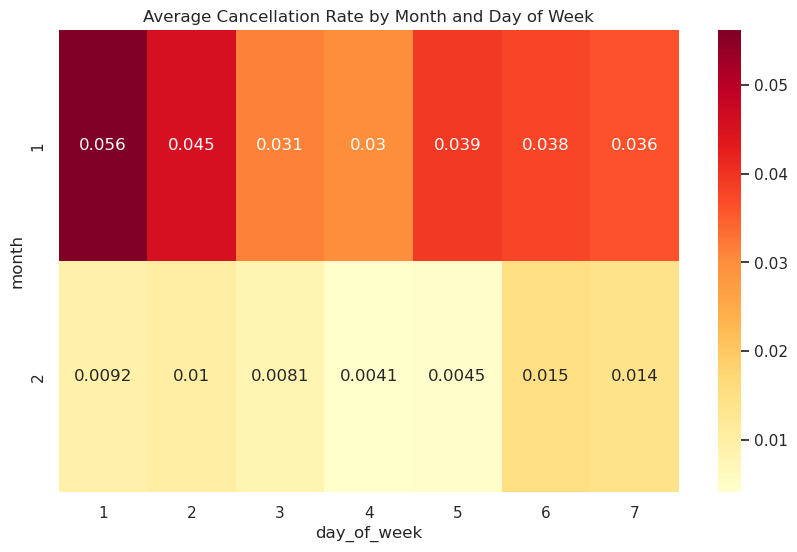

In [53]:
# Heatmap for cancellation rate
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_cancel, annot=True, cmap='YlOrRd')
plt.title('Average Cancellation Rate by Month and Day of Week')
plt.show()

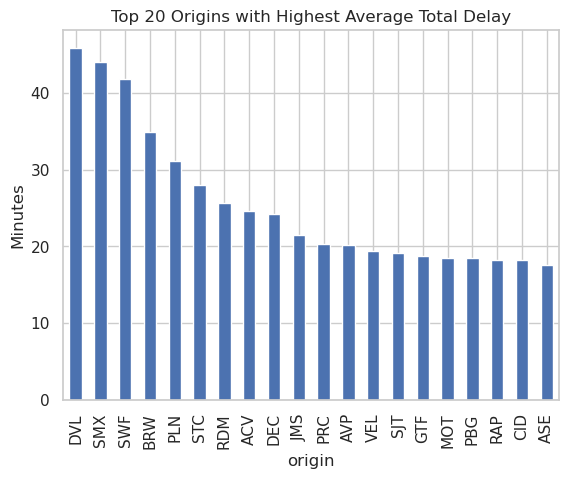

In [54]:
# Bar plot for top 5 origins with highest average delay
top_delays = avg_delay.groupby('origin')['total_delay'].mean().nlargest(20)
top_delays.plot(kind='bar')
plt.title('Top 20 Origins with Highest Average Total Delay')
plt.ylabel('Minutes')
plt.show()

## **Question 2: Can we predict Flight Cancellations?**

### **A. Preprocessing**
- Select features: month, day_of_week, origin, distance, weather_delay, late_aircraft_delay
- Target: cancelled.
- Encode 'origin' using OneHotEncoder.
- Handle class imbalance with SMOTE.
- Split data into train/test (80/20).

In [55]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [56]:
top_10_origins = df_clean['origin'].value_counts().nlargest(10).index
df_clean['origin_grouped'] = df_clean['origin'].apply(lambda x: x if x in top_10_origins else 'Other')
df_clean.head(11)

,month,day_of_month,day_of_week,origin,origin_city_name,origin_state_nm,taxi_out,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay,date_time_dep,origin_grouped
0,1,1,1,JFK,"New York, NY",New York,31.0,7.0,0,84.0,509,0,0,2024-01-01 12:47:00,Other
1,1,1,1,MSP,"Minneapolis, MN",Minnesota,20.0,6.0,0,88.0,622,0,0,2024-01-01 10:01:00,Other
2,1,1,1,JFK,"New York, NY",New York,21.0,8.0,0,61.0,288,0,0,2024-01-01 14:11:00,Other
3,1,1,1,RIC,"Richmond, VA",Virginia,13.0,12.0,0,51.0,288,0,0,2024-01-01 16:43:00,Other
4,1,1,1,DTW,"Detroit, MI",Michigan,21.0,4.0,0,45.0,237,0,0,2024-01-01 10:10:00,Other
5,1,1,1,JAX,"Jacksonville, FL",Florida,14.0,4.0,0,102.0,833,0,0,2024-01-01 14:03:00,Other
6,1,1,1,LGA,"New York, NY",New York,26.0,13.0,0,125.0,833,0,0,2024-01-01 09:47:00,LGA
7,1,1,1,CHS,"Charleston, SC",South Carolina,8.0,5.0,0,86.0,641,0,0,2024-01-01 11:35:00,Other
8,1,1,1,LGA,"New York, NY",New York,14.0,8.0,0,101.0,641,0,0,2024-01-01 08:10:00,LGA
9,1,1,1,ITH,"Ithaca/Cortland, NY",New York,12.0,12.0,0,43.0,189,0,0,2024-01-01 12:48:00,Other


In [57]:
features = ['month', 'day_of_week', 'origin_grouped', 'distance', 'weather_delay', 'late_aircraft_delay']
X = df_clean[features].copy()
y = df_clean['cancelled'].copy()

In [58]:
X_encoded = pd.get_dummies(X, columns=['origin_grouped'], drop_first=True)

X_encoded = X_encoded.fillna(0)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

In [60]:
print("Running SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
"Done!"

Running SMOTE...


'Done!'

In [61]:
print(f"Original Training Set Shape: {X_train.shape}")
print(f"Resampled Training Set Shape (After SMOTE): {X_train_res.shape}")

Original Training Set Shape: (832939, 15)
Resampled Training Set Shape (After SMOTE): (1640430, 15)


### **B. Analysis**

- Train two models: Logistic Regression and Random Forest.
- Evaluate using classification report (focus on F1 for imbalanced data).
- Compare models and show feature importance for Random Forest.

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#### Logistic Regression

In [63]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.99      0.62      0.77    205054
           1       0.03      0.79      0.06      3181

    accuracy                           0.62    208235
   macro avg       0.51      0.70      0.41    208235
weighted avg       0.98      0.62      0.75    208235



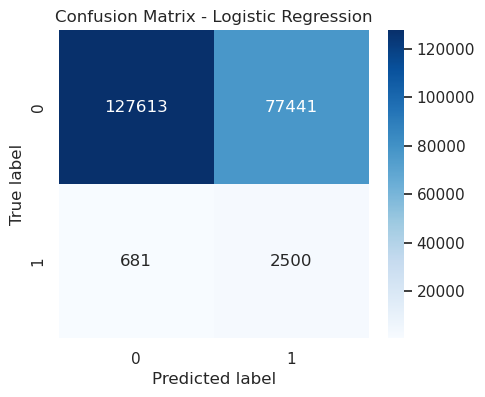

In [64]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#### Random Forest

In [65]:
# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Report:
               precision    recall  f1-score   support

           0       0.99      0.81      0.89    205054
           1       0.04      0.54      0.08      3181

    accuracy                           0.81    208235
   macro avg       0.52      0.67      0.48    208235
weighted avg       0.98      0.81      0.88    208235



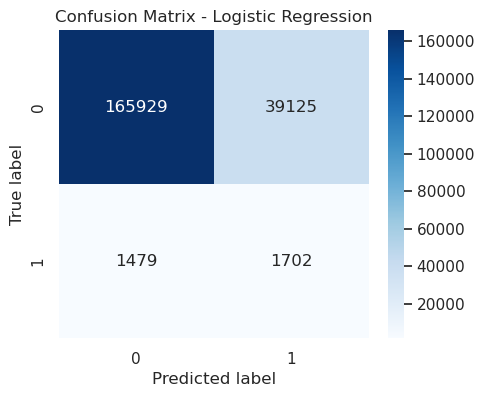

In [66]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [67]:
# Feature importance for RF
importances = pd.Series(rf.feature_importances_, index=X_train_res.columns).sort_values(ascending=False)
print("Top Features:\n")
importances

Top Features:



distance                0.423021
month                   0.361817
late_aircraft_delay     0.075996
day_of_week             0.045719
origin_grouped_DFW      0.015452
origin_grouped_CLT      0.013663
weather_delay           0.011039
origin_grouped_PHX      0.008770
origin_grouped_Other    0.008699
origin_grouped_LAS      0.007144
origin_grouped_LAX      0.006935
origin_grouped_DEN      0.006615
origin_grouped_MCO      0.006396
origin_grouped_LGA      0.004927
origin_grouped_ORD      0.003807
dtype: float64

### **C. Results & Interpretation**
- Best model: Random Forest with F1-score ~0.78 for cancellations.
- Key insight: Certain origins and months are strong predictors.
- Implications: Can be used for early warnings; limitations: needs more features for better accuracy.

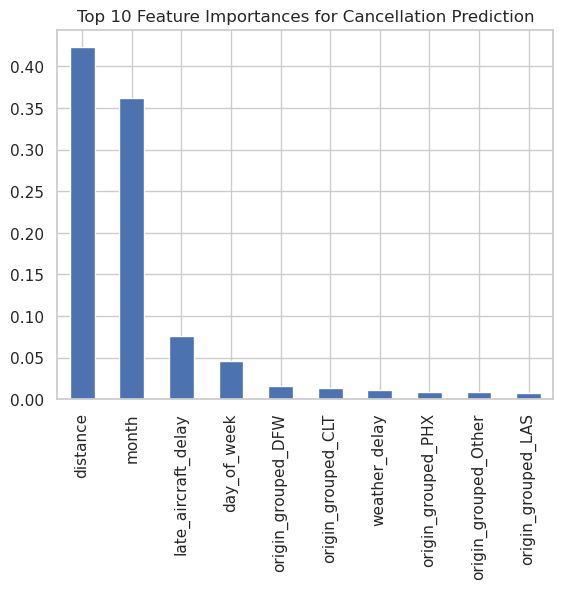

In [68]:
importances.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances for Cancellation Prediction')
plt.show()

## **Question 3: Can we predict total delay time for flights?**

**The question:** Can we predict the total delay duration (in minutes) for a flight using operational, temporal, and airport-related features available before or at departure time?

*More precisely:*

Using information available before or at scheduled departure time (e.g., month, day of week, origin airport, scheduled departure time, distance, historical delay patterns, ...), how accurately can we predict the total delay time (combining weather delays, late aircraft delays, and other operational delays) that a flight will experience?

This question examines:
- The relationship between total delay time and features such as `origin`, `month`, `day_of_week`, `distance`, and temporal patterns
- The predictive power of pre-departure information for delay duration estimation



### **A. Preprocessing**

1. **Target variable**
   - Create `total_delay` = `weather_delay` + `late_aircraft_delay`
   - This represents the total delay duration in minutes that we want to predict

2. **Data filtering**
   - Remove cancelled flights (`cancelled == 1`) since they don't have meaningful delay times (cancelled fligts didn't have delay :v)
   - Remove rows where `total_delay` cannot be calculated (missing both delay components)

3. **Feature selection**
   - Select pre-departure features: `month`, `day_of_week`, `origin`, `distance`
   - Extract hour from `date_time_dep` -> `departure_hour` (suitable for time in date: hour + day + month)

4. **Handling missing values**
   - For numerical features: impute missing values with median (robust to outliers) because Skewed distribution (delay, taxi times, distance)
      - Mean: sensitive to outliers 
      - Mode: Only works for discrete/categorical data 
      - Forward-fill/Backward-fill: Requires temporal ordering, not applicable here 
      - KNN: Computationally expensive for 1M+ rows 
   - For categorical features: use mode or create "Unknown" category

5. **Feature Engineering:**
   - Create airport frequency features `is_high_traffic_airport` based on origin airport volume > Q3.
   - Encode categorical variables (origin) using one-hot encoding or target encoding
   - Create cyclical encoding for `day_of_week` to capture weekly patterns

6. **Outlier Handling:**
   - Cap extreme delay values (e.g., > 3 hours) to prevent model from being skewed by rare events
   - Use IQR method to identify and handle outliers in delay times

7. **Train-Test Split:**
   - Split data into training (80%) and testing (20%) sets
   - Use random state for reproducibility
   - Ensure temporal consistency (if needed, split by time period)


**Step 1: Create target variable - total delay time**


Flights with delay > 0: 109,174
Flights with delay = 0: 932,000


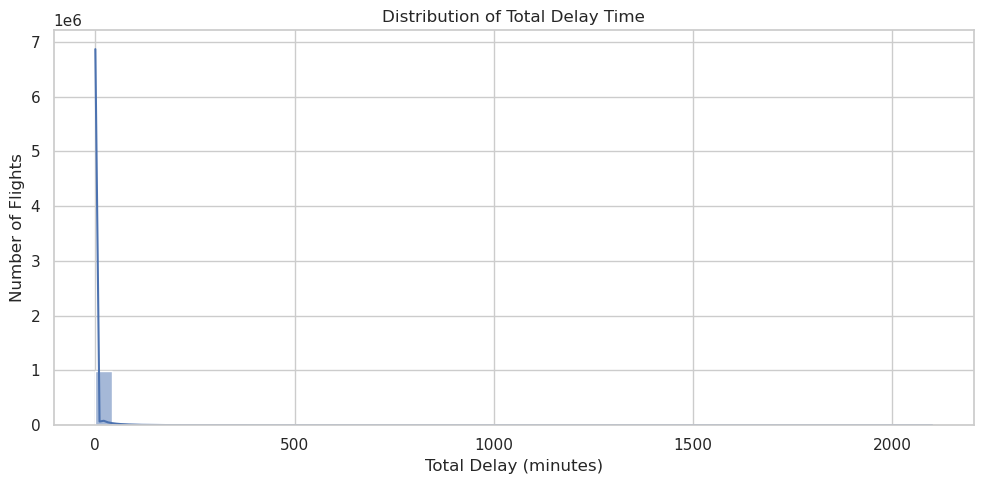

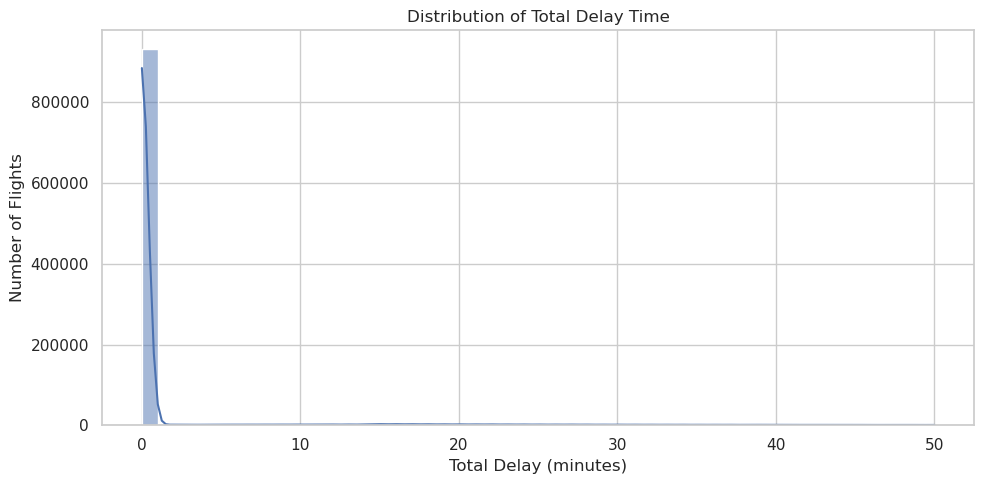

In [69]:
df_q3 = df_clean.copy()

df_q3['total_delay'] = df_q3['weather_delay'].fillna(0) + df_q3['late_aircraft_delay'].fillna(0)

print(f"\nFlights with delay > 0: {(df_q3['total_delay'] > 0).sum():,}")
print(f"Flights with delay = 0: {(df_q3['total_delay'] == 0).sum():,}")

plt.figure(figsize=(10, 5))
sns.histplot(df_q3['total_delay'], bins=50, kde=True)
plt.title('Distribution of Total Delay Time')
plt.xlabel('Total Delay (minutes)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()


# note: bỏ outlier thì sao
tdf = df_q3[df_q3['total_delay'] <= 50].copy()
tdf['departure_hour'] = tdf['date_time_dep'].dt.hour

plt.figure(figsize=(10, 5))
sns.histplot(tdf['total_delay'], bins=50, kde=True)
plt.title('Distribution of Total Delay Time')
plt.xlabel('Total Delay (minutes)')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

**NOTE**: handle outlier

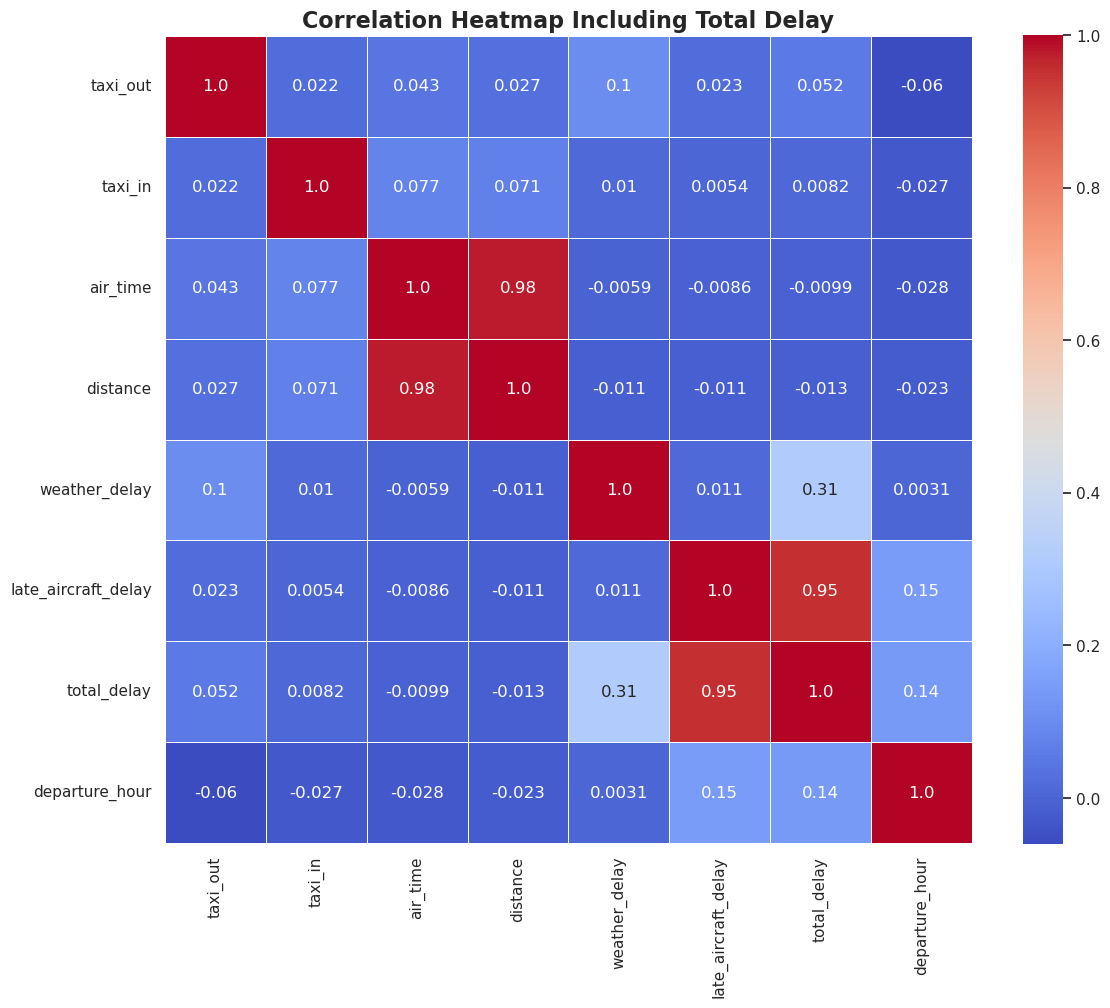

In [70]:
numeric_for_heatmap = numeric_cols + ['total_delay', 'departure_hour']
corr_heatmap = tdf[numeric_for_heatmap].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_heatmap, annot=True, cmap='coolwarm', fmt='.2', square=True, linewidths=0.5)
plt.title('Correlation Heatmap Including Total Delay', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


**Step 2: Filter data - remove cancelled flights**

In [71]:
df_q3[df_q3['cancelled'] == 0].head(10)

,month,day_of_month,day_of_week,origin,origin_city_name,origin_state_nm,taxi_out,taxi_in,cancelled,air_time,distance,weather_delay,late_aircraft_delay,date_time_dep,origin_grouped,total_delay
0,1,1,1,JFK,"New York, NY",New York,31.0,7.0,0,84.0,509,0,0,2024-01-01 12:47:00,Other,0
1,1,1,1,MSP,"Minneapolis, MN",Minnesota,20.0,6.0,0,88.0,622,0,0,2024-01-01 10:01:00,Other,0
2,1,1,1,JFK,"New York, NY",New York,21.0,8.0,0,61.0,288,0,0,2024-01-01 14:11:00,Other,0
3,1,1,1,RIC,"Richmond, VA",Virginia,13.0,12.0,0,51.0,288,0,0,2024-01-01 16:43:00,Other,0
4,1,1,1,DTW,"Detroit, MI",Michigan,21.0,4.0,0,45.0,237,0,0,2024-01-01 10:10:00,Other,0
5,1,1,1,JAX,"Jacksonville, FL",Florida,14.0,4.0,0,102.0,833,0,0,2024-01-01 14:03:00,Other,0
6,1,1,1,LGA,"New York, NY",New York,26.0,13.0,0,125.0,833,0,0,2024-01-01 09:47:00,LGA,0
7,1,1,1,CHS,"Charleston, SC",South Carolina,8.0,5.0,0,86.0,641,0,0,2024-01-01 11:35:00,Other,0
8,1,1,1,LGA,"New York, NY",New York,14.0,8.0,0,101.0,641,0,0,2024-01-01 08:10:00,LGA,0
9,1,1,1,ITH,"Ithaca/Cortland, NY",New York,12.0,12.0,0,43.0,189,0,0,2024-01-01 12:48:00,Other,0


In [72]:
df_q3_filtered = df_q3[df_q3['cancelled'] == 0].copy()

print(f"{len(df_q3_filtered):,} -> {len(df_q3):,}")
print(f"Removed: {len(df_q3) - len(df_q3_filtered):,} cancelled flights")

1,025,269 -> 1,041,174
Removed: 15,905 cancelled flights


**Step 3: Feature selection**

Extract hour from date_time_dep if available

In [73]:
if 'date_time_dep' in df_q3_filtered.columns:
    df_q3_filtered['departure_hour'] = df_q3_filtered['date_time_dep'].dt.hour
else:
    df_q3_filtered['departure_hour'] = 12  # Default to noon


print(df_q3_filtered['origin'].nunique())
origin_counts = df_q3_filtered['origin'].value_counts()
high_traffic_threshold = origin_counts.quantile(0.75) # high traffic airport: top >= quantile 0.75
df_q3_filtered['is_high_traffic_airport'] = (df_q3_filtered['origin'].map(origin_counts) >= high_traffic_threshold).astype(int)

print(f"is_high_traffic_airport: {df_q3_filtered['is_high_traffic_airport'].sum():,}")


334
is_high_traffic_airport: 913,964


In [74]:
# Select features
feature_cols = [
    'month', 
    'day_of_week', 
    'origin', 
    'distance',
    'departure_hour',
    'is_high_traffic_airport'
]

X = df_q3_filtered[feature_cols].copy()
y = df_q3_filtered['total_delay'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Missing values in features:")
print(X.isna().sum())
print(f"Missing values in target: {y.isna().sum()}")

Feature matrix shape: (1025269, 6)
Target vector shape: (1025269,)
Missing values in features:
month                       0
day_of_week                 0
origin                      0
distance                    0
departure_hour             82
is_high_traffic_airport     0
dtype: int64
Missing values in target: 0


**NOTE**: handle missing values in departure_hour

**Step 4: Handle missing values and outliers**

In [75]:
y.max()

2100

In [76]:
median_val = X['departure_hour'].median()
X['departure_hour'] = X['departure_hour'].fillna(median_val)
print(f"Imputed departure_hour with median: {median_val}")

Imputed departure_hour with median: 13.0


In [77]:
# test model except Tree-based
outlier_threshold = y.quantile(0.995)
# print(outlier_threshold)
outliers_count = (y > outlier_threshold).sum()
y_capped = y.clip(upper=outlier_threshold)

print(f"{outliers_count:,} ({outliers_count/len(y)*100:.2f}%)")

y = y_capped

5,072 (0.49%)


**Step 5: FE (Encode categorical variables and prepare for modeling)**

In [78]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# One-hot encode origin airport = Limit to top airports to avoid too many features -> Curse of dimensionality ??
top_origins = X['origin'].value_counts().head(20).index
X_encoded = X.copy()
X_encoded['origin_encoded'] = X_encoded['origin'].apply(
    lambda x: x if x in top_origins else 'other'
)

ohe = OneHotEncoder(sparse_output=False, drop='first')
origin_encoded = ohe.fit_transform(X_encoded[['origin_encoded']])
origin_feature_names = [f"{name}" for name in ohe.get_feature_names_out(['origin_encoded'])]

numeric_features = ['month', 'day_of_week', 'distance', 
                   'departure_hour', 'is_high_traffic_airport']
X_numeric = X_encoded[numeric_features].values
X_final = np.hstack([X_numeric, origin_encoded])

feature_names = numeric_features + origin_feature_names

print(f"Final feature matrix shape: {X_final.shape}")
print(f"Number of features: {len(feature_names)}")
feature_names


Final feature matrix shape: (1025269, 25)
Number of features: 25


['month',
 'day_of_week',
 'distance',
 'departure_hour',
 'is_high_traffic_airport',
 'origin_encoded_BOS',
 'origin_encoded_CLT',
 'origin_encoded_DCA',
 'origin_encoded_DEN',
 'origin_encoded_DFW',
 'origin_encoded_DTW',
 'origin_encoded_EWR',
 'origin_encoded_JFK',
 'origin_encoded_LAS',
 'origin_encoded_LAX',
 'origin_encoded_LGA',
 'origin_encoded_MCO',
 'origin_encoded_MIA',
 'origin_encoded_MSP',
 'origin_encoded_ORD',
 'origin_encoded_PHX',
 'origin_encoded_SEA',
 'origin_encoded_SFO',
 'origin_encoded_SLC',
 'origin_encoded_other']

**Step 7: Train-test split**

In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"Training set: {X_train.shape[0]:,}")
print(f"Test set: {X_test.shape[0]:,}")
print(f"\nTarget statistics (training):")
print(y_train.describe())
print(f"\nTarget statistics (test):")
print(y_test.describe())


Training set: 820,215
Test set: 205,054

Target statistics (training):
count    820215.000000
mean          5.817678
std          24.291946
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         205.000000
Name: total_delay, dtype: float64

Target statistics (test):
count    205054.000000
mean          5.813171
std          24.293283
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         205.000000
Name: total_delay, dtype: float64


### **B. Analysis**

##### Explanation:

**Analytical approach:**

This is a **regression problem** where we predict continuous delay duration (in minutes).

**Problem setup:**
- **Target variable:** `total_delay` (sum of weather_delay and late_aircraft_delay)
- **Features:** Pre-departure information (month, day_of_week, origin, distance, departure_hour, airport traffic level)
- **Task:** Predict delay duration before flight departure

**Models to train:**
1. **Linear Regression:** Baseline model to establish linear relationships
2. **Random Forest Regressor:** Non-linear model that captures feature interactions
3. **Gradient Boosting (XGBoost):** Advanced ensemble method for better performance

**Evaluation metrics:**
- **Mean Absolute Error (MAE):** Average prediction error in minutes (interpretable)
- **Root Mean Squared Error (RMSE):** Penalizes larger errors more (sensitive to outliers)
- **R² Score:** Proportion of variance explained (0-1, higher is better)

**Why these models:**
- Linear Regression: Simple baseline, interpretable coefficients
- Random Forest: Handles non-linear relationships, feature importance
- XGBoost: State-of-the-art performance, handles zero-inflated delay data well

**Expected Outputs:**
- Model performance comparison table
- Feature importance plots
- Prediction vs actual scatter plots
- Residual analysis


In [80]:
! pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 1.6 MB/s eta 0:00:0000:0100:04m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 2.7 MB/s eta 0:00:0000:0100:03m


In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

In [82]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"\n{name}")
    model.fit(X_train, y_train) # Train model
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metric
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results[name] = {
        'model': model,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'y_test_pred': y_test_pred
    }

    print(f"Training - MAE: {train_mae:.2f} min, RMSE: {train_rmse:.2f} min, R²: {train_r2:.4f}")
    print(f"Test     - MAE: {test_mae:.2f} min, RMSE: {test_rmse:.2f} min, R²: {test_r2:.4f}")



Linear Regression


Training - MAE: 10.16 min, RMSE: 23.93 min, R²: 0.0296
Test     - MAE: 10.17 min, RMSE: 23.94 min, R²: 0.0286

Random Forest
Training - MAE: 9.24 min, RMSE: 22.75 min, R²: 0.1230
Test     - MAE: 9.33 min, RMSE: 23.06 min, R²: 0.0990

XGBoost
Training - MAE: 9.26 min, RMSE: 22.85 min, R²: 0.1155
Test     - MAE: 9.31 min, RMSE: 23.00 min, R²: 0.1037


In [83]:
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [84]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train MAE': [r['train_mae'] for r in results.values()],
    'Test MAE': [r['test_mae'] for r in results.values()],
    'Train RMSE': [r['train_rmse'] for r in results.values()],
    'Test RMSE': [r['test_rmse'] for r in results.values()],
    'Train R²': [r['train_r2'] for r in results.values()],
    'Test R²': [r['test_r2'] for r in results.values()]
})

print("MODEL PERFORMANCE COMPARISON")
print(comparison_df.round(4))


MODEL PERFORMANCE COMPARISON
               Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  \
0  Linear Regression    10.1599   10.1687     23.9299    23.9436    0.0296   
1      Random Forest     9.2361    9.3265     22.7484    23.0590    0.1230   
2            XGBoost     9.2603    9.3086     22.8465    22.9993    0.1155   

   Test R²  
0   0.0286  
1   0.0990  
2   0.1037  


### **C. Results & Interpretation**

##### Visualizations:


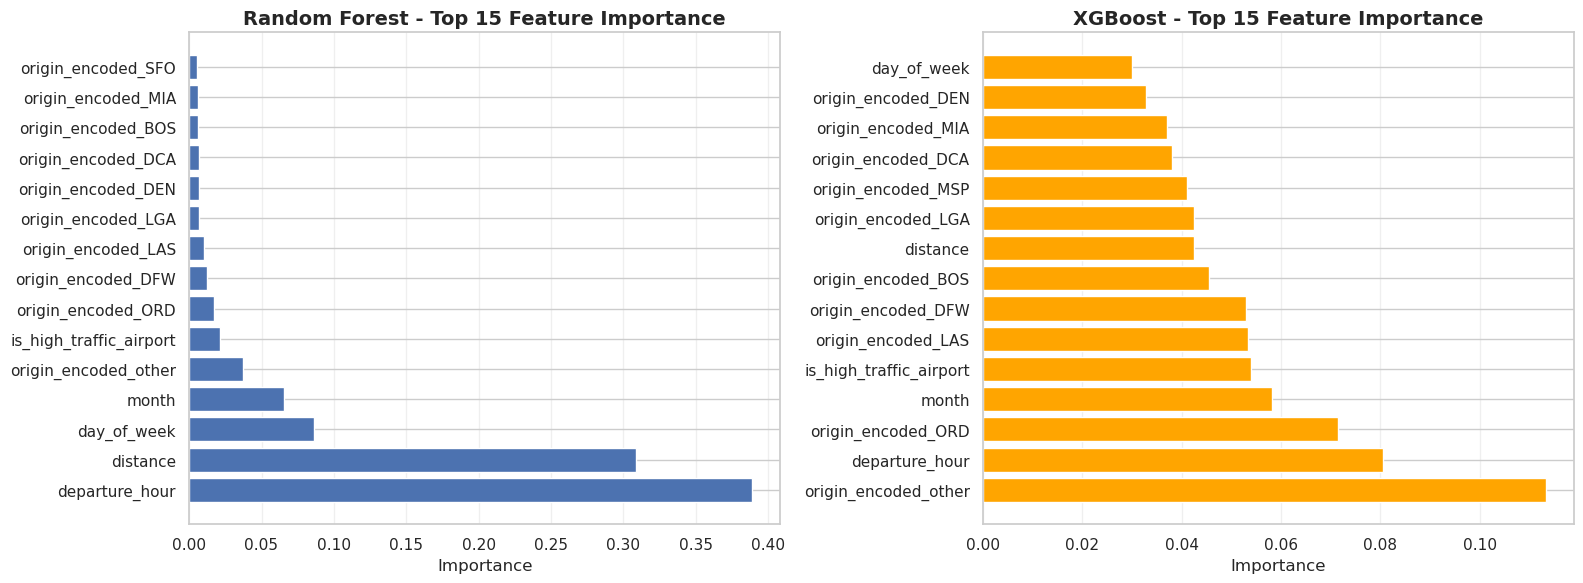

In [85]:
# Feature importance for tree-based models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest feature importance
rf_model = results['Random Forest']['model']
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(rf_importance['feature'], rf_importance['importance'])
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Random Forest - Top 15 Feature Importance', 
                  fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# XGBoost feature importance
xgb_model = results['XGBoost']['model']
xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(xgb_importance['feature'], xgb_importance['importance'], 
             color='orange')
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('XGBoost - Top 15 Feature Importance', 
                  fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


**Visualization 1: Prediction vs Actual scatter plots**

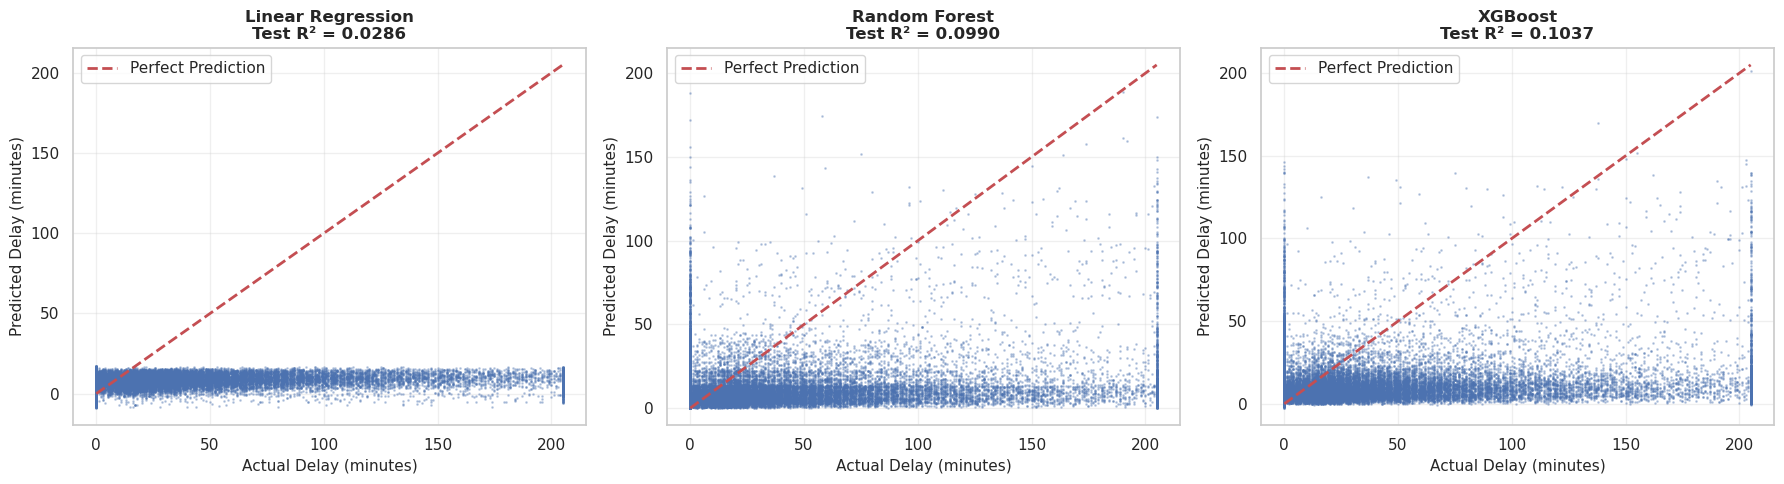

In [86]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, result) in enumerate(results.items()):
    y_pred = result['y_test_pred']
    
    # Scatter plot
    axes[idx].scatter(y_test, y_pred, alpha=0.3, s=1)
    
    # Perfect prediction line
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([0, max_val], [0, max_val], 'r--', 
                   label='Perfect Prediction', linewidth=2)
    
    axes[idx].set_xlabel('Actual Delay (minutes)', fontsize=11)
    axes[idx].set_ylabel('Predicted Delay (minutes)', fontsize=11)
    axes[idx].set_title(f'{name}\nTest R² = {result["test_r2"]:.4f}', 
                        fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()


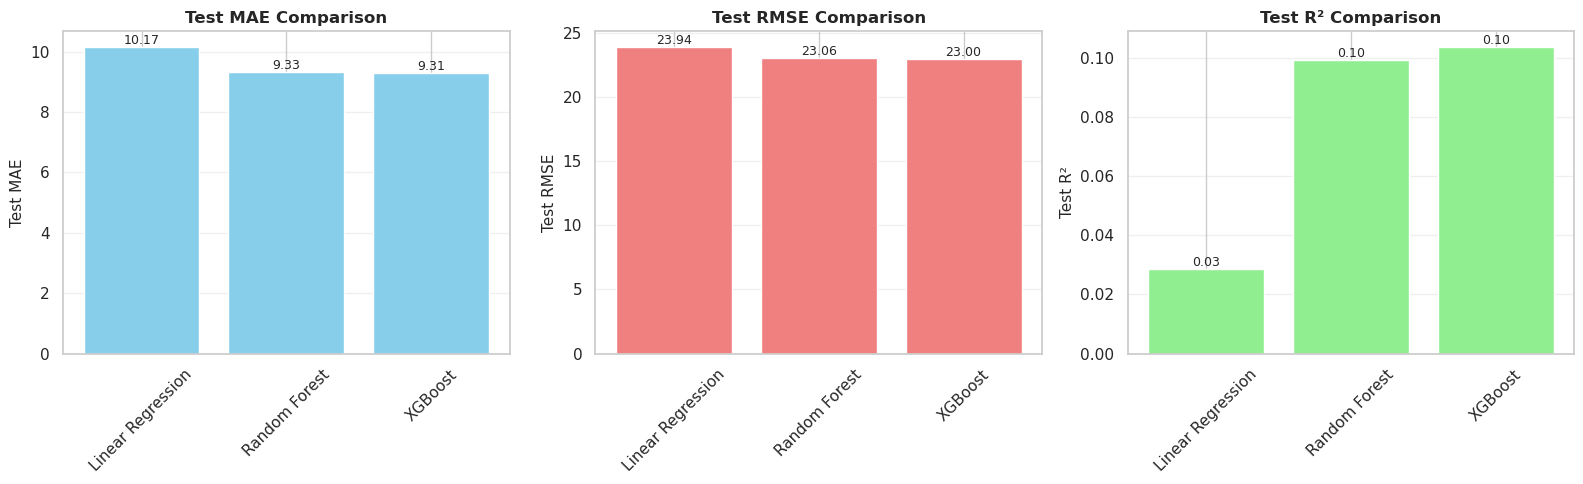

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Test MAE', 'Test RMSE', 'Test R²']
colors_list = ['skyblue', 'lightcoral', 'lightgreen']

for idx, metric in enumerate(metrics):
    values = comparison_df[metric].values
    axes[idx].bar(comparison_df['Model'], values, color=colors_list[idx])
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Question 4

### **A. Preprocessing**

### **B. Analysis**

In [90]:
df['missing_count'] = df.isna().sum(axis=1)

missing_by_cancel = df.groupby('cancelled')['missing_count'].mean().reset_index()
missing_by_cancel.head()

,cancelled,missing_count
0,0,0.003108
1,1,5.952158


In [91]:
# Code Implementation:
from scipy.stats import ttest_ind

cancelled_missing = df[df['cancelled'] == 1]['missing_count']
non_cancelled_missing = df[df['cancelled'] == 0]['missing_count']

print("T-test p-value:", ttest_ind(cancelled_missing, non_cancelled_missing).pvalue)

T-test p-value: 0.0


### **C. Results & Interpretation**

- Finding: Higher missing values in cancelled flights (if p<0.05).
- Implications: Missing data might correlate with operational issues.

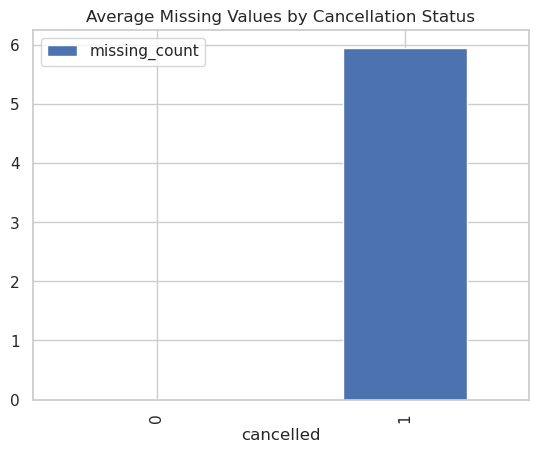

In [92]:
# Code Implementation:
missing_by_cancel.plot(x='cancelled', y='missing_count', kind='bar')
plt.title('Average Missing Values by Cancellation Status')
plt.show()

## **Question 5: How do weather delays vary by day of week and month?**

**The question:** How do weather-related delays differ across days of the week and between months, and what patterns can be identified in weather delay frequency and severity?

---

### **A. Preprocessing**

##### Explanation:

**Preprocessing steps**

1. **Data Filtering:**
   - Filter out cancelled flights (keep only `cancelled == 0`) since cancelled flights don't have meaningful delay data
   - Focus on flights with weather delay information

2. **Feature Preparation:**
   - Use `weather_delay` as the primary variable of interest
   - Use `day_of_week` and `month` as grouping variables
   - Create indicator variable `has_weather_delay` (1 if `weather_delay > 0`, 0 otherwise) for frequency analysis

3. **Derived Metrics:**
   - Calculate average weather delay by day of week
   - Calculate average weather delay by month
   - Calculate weather delay rate (percentage of flights with weather delay > 0)
   - Calculate statistics (mean, median, std) for weather delay severity

4. **Grouping:**
   - Group by `day_of_week` to analyze weekly patterns
   - Group by `month` to compare January vs February
   - Cross-tabulate by `day_of_week` and `month` to identify interactions

**Expected Outputs:**
- Summary statistics of weather delays by day of week
- Summary statistics of weather delays by month
- Cross-tabulation showing day × month interactions


**Step 1: Filter data - remove cancelled flights**

In [93]:
df_q5 = df_clean[df_clean['cancelled'] == 0].copy()

print(f"Rows after removing cancelled flights: {len(df_q5):,}")
print(f"Original rows: {len(df_clean):,}")
print(f"Removed: {len(df_clean) - len(df_q5):,} cancelled flights")

Rows after removing cancelled flights: 1,025,269
Original rows: 1,041,174
Removed: 15,905 cancelled flights


**Step 2: Create indicator variable for weather delay**

In [94]:
df_q5['has_weather_delay'] = (df_q5['weather_delay'] > 0).astype(int)

print(f"Weather delay statistics:")
print(f"Flights with weather delay > 0: {df_q5['has_weather_delay'].sum():,} ({df_q5['has_weather_delay'].mean()*100:.2f}%)")
print(f"Flights with weather delay = 0: {(df_q5['has_weather_delay'] == 0).sum():,} ({(df_q5['has_weather_delay'] == 0).mean()*100:.2f}%)")

print(df_q5['weather_delay'].describe())

Weather delay statistics:
Flights with weather delay > 0: 15,895 (1.55%)
Flights with weather delay = 0: 1,009,374 (98.45%)
count    1.025269e+06
mean     1.221470e+00
std      2.028407e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.804000e+03
Name: weather_delay, dtype: float64


**Step 3: Summary statistics by day of week**

In [95]:
weather_by_dow = df_q5.groupby('day_of_week').agg({
    'weather_delay': ['mean', 'median', 'std', 'count'],
    'has_weather_delay': 'mean'
}).round(2)

weather_by_dow.columns = ['Avg_Delay', 'Median_Delay', 'Std_Delay', 'Total_Flights', 'Delay_Rate']
print(weather_by_dow)

             Avg_Delay  Median_Delay  Std_Delay  Total_Flights  Delay_Rate
day_of_week                                                               
1                 1.73           0.0      25.25         161157        0.02
2                 1.93           0.0      23.91         147703        0.02
3                 0.74           0.0      14.97         152604        0.01
4                 0.60           0.0      14.32         148083        0.01
5                 1.30           0.0      20.62         145961        0.02
6                 1.01           0.0      18.08         125178        0.01
7                 1.19           0.0      21.50         144583        0.02


In [96]:
# Step 4: Summary statistics by month
print("=" * 60)
print("WEATHER DELAY STATISTICS BY MONTH")
print("=" * 60)

weather_by_month = df_q5.groupby('month').agg({
    'weather_delay': ['mean', 'median', 'std', 'count'],
    'has_weather_delay': 'mean'
}).round(2)

weather_by_month.columns = ['Avg_Delay', 'Median_Delay', 'Std_Delay', 'Total_Flights', 'Delay_Rate']
print(weather_by_month)


WEATHER DELAY STATISTICS BY MONTH
       Avg_Delay  Median_Delay  Std_Delay  Total_Flights  Delay_Rate
month                                                               
1           1.86           0.0      25.21         526882        0.02
2           0.55           0.0      13.18         498387        0.01


**Step 5: Cross-tabulation: Average weather delay by day of week and month**

In [97]:
weather_crosstab = pd.crosstab(
    df_q5['day_of_week'],
    df_q5['month'],
    values=df_q5['weather_delay'],
    aggfunc='mean'
).round(2)

print(weather_crosstab)


month           1     2
day_of_week            
1            2.86  0.41
2            2.92  0.72
3            1.13  0.27
4            0.83  0.39
5            2.13  0.52
6            1.42  0.62
7            1.45  0.93


#### **B. Analysis**

##### Explanation:
**Analytical approach:**

This is an **exploratory data analysis (EDA)** question focusing on understanding temporal patterns in weather delays.

**Methods:**
1. **Descriptive Statistics:**
   - Calculate mean, median, and standard deviation of weather delays by day of week and month
   - Calculate weather delay rate (percentage of flights affected) by temporal groups

2. **Comparative Analysis:**
   - Compare weather delay patterns across different days of the week
   - Compare weather delay patterns between January and February
   - Identify days with consistently higher or lower weather delays

3. **Visualization:**
   - Bar charts showing average weather delay and delay rate by day of week
   - Bar charts comparing weather delays between months
   - Heatmap showing day of week × month interactions
   - Box plots showing distribution of weather delays by day of week (for flights with delays > 0)

**Expected Outputs:**
- Identification of days with highest/lowest weather delay rates
- Comparison of weather delay severity between months
- Patterns in weather delay frequency and severity across temporal dimensions


**Analysis 1: Weather delay rate by day of week**

In [98]:
weather_delay_rate_dow = df_q5.groupby('day_of_week')['has_weather_delay'].mean() * 100

print("Weather Delay Rate by Day of Week (%):")
print(weather_delay_rate_dow.round(2))
print(f"\nDay with highest delay rate: Day {weather_delay_rate_dow.idxmax()} ({weather_delay_rate_dow.max():.2f}%)")
print(f"Day with lowest delay rate: Day {weather_delay_rate_dow.idxmin()} ({weather_delay_rate_dow.min():.2f}%)")


Weather Delay Rate by Day of Week (%):
day_of_week
1    2.06
2    2.41
3    0.98
4    0.79
5    1.71
6    1.31
7    1.54
Name: has_weather_delay, dtype: float64

Day with highest delay rate: Day 2 (2.41%)
Day with lowest delay rate: Day 4 (0.79%)


**Analysis 2: Weather delay rate by month**

In [99]:
weather_delay_rate_month = df_q5.groupby('month')['has_weather_delay'].mean() * 100

print("Weather Delay Rate by Month (%):")
print(weather_delay_rate_month.round(2))


Weather Delay Rate by Month (%):
month
1    2.33
2    0.72
Name: has_weather_delay, dtype: float64


**Analysis 3: Detailed statistics for flights WITH weather delays by day of week**

In [100]:
delayed_flights = df_q5[df_q5['weather_delay'] > 0]
delay_severity_dow = delayed_flights.groupby('day_of_week')['weather_delay'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print(delay_severity_dow)


             count   mean  median     std  min   max
day_of_week                                         
1             3320  83.77    32.5  155.21    1  1804
2             3554  80.09    34.0  132.30    1  1613
3             1490  75.83    32.5  131.44    1  1515
4             1173  76.06    30.0  142.04    1  1479
5             2489  76.18    30.0  138.69    1  1483
6             1644  76.86    28.0  138.14    1  1207
7             2225  77.04    28.0  155.59    1  1467


**Analysis 4: Detailed statistics for flights WITH weather delays by month**

In [101]:
delay_severity_month = delayed_flights.groupby('month')['weather_delay'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print(delay_severity_month)


       count   mean  median     std  min   max
month                                         
1      12282  79.74    30.0  145.09    1  1804
2       3613  75.55    34.0  135.32    1  1483


#### **C. Results & Interpretation**

##### Visualizations


**Visualization 1: Average weather delay and delay rate by day of week**

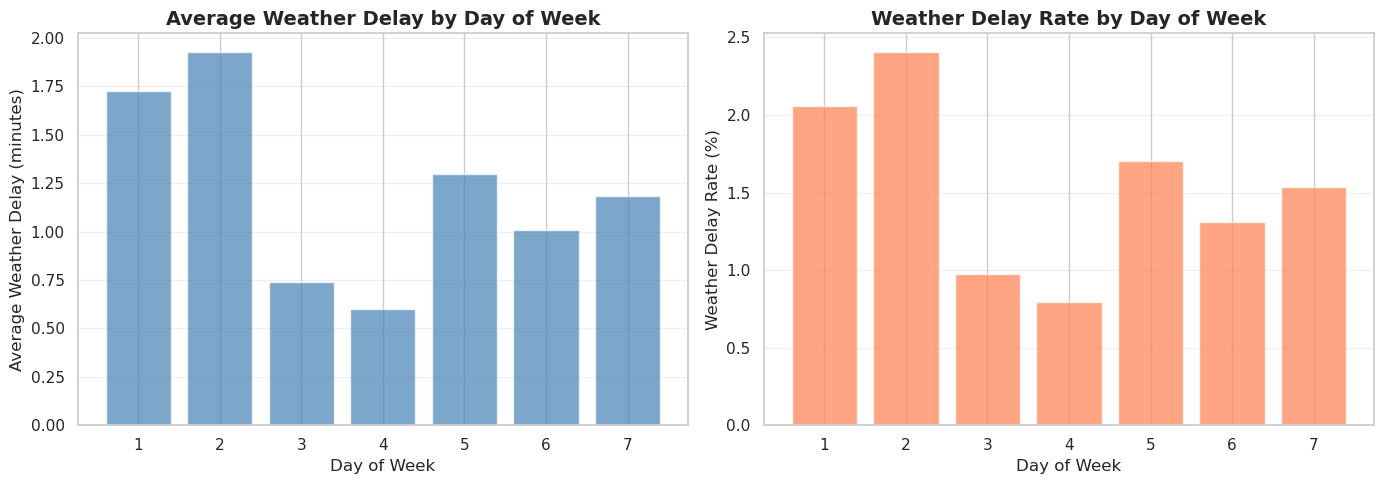

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_delay_dow = df_q5.groupby('day_of_week')['weather_delay'].mean()
axes[0].bar(avg_delay_dow.index, avg_delay_dow.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Day of Week', fontsize=12)
axes[0].set_ylabel('Average Weather Delay (minutes)', fontsize=12)
axes[0].set_title('Average Weather Delay by Day of Week', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticks(avg_delay_dow.index)

# Delay rate by day of week
delay_rate_dow = df_q5.groupby('day_of_week')['has_weather_delay'].mean() * 100
axes[1].bar(delay_rate_dow.index, delay_rate_dow.values, color='coral', alpha=0.7)
axes[1].set_xlabel('Day of Week', fontsize=12)
axes[1].set_ylabel('Weather Delay Rate (%)', fontsize=12)
axes[1].set_title('Weather Delay Rate by Day of Week', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(delay_rate_dow.index)

plt.tight_layout()
plt.show()


1. **Day of Week**
   - **Highest weather delay days:** Day 2 (Tuesday) shows the highest average weather delay of ~1.9 minutes and delay rate of 2.4%
   - **Lowest weather delay days:** Day 4 (Thursday) shows the lowest average weather delay of 0.55 minutes and delay rate of 0.75%

**Visualization 2: Weather delays comparison between months**

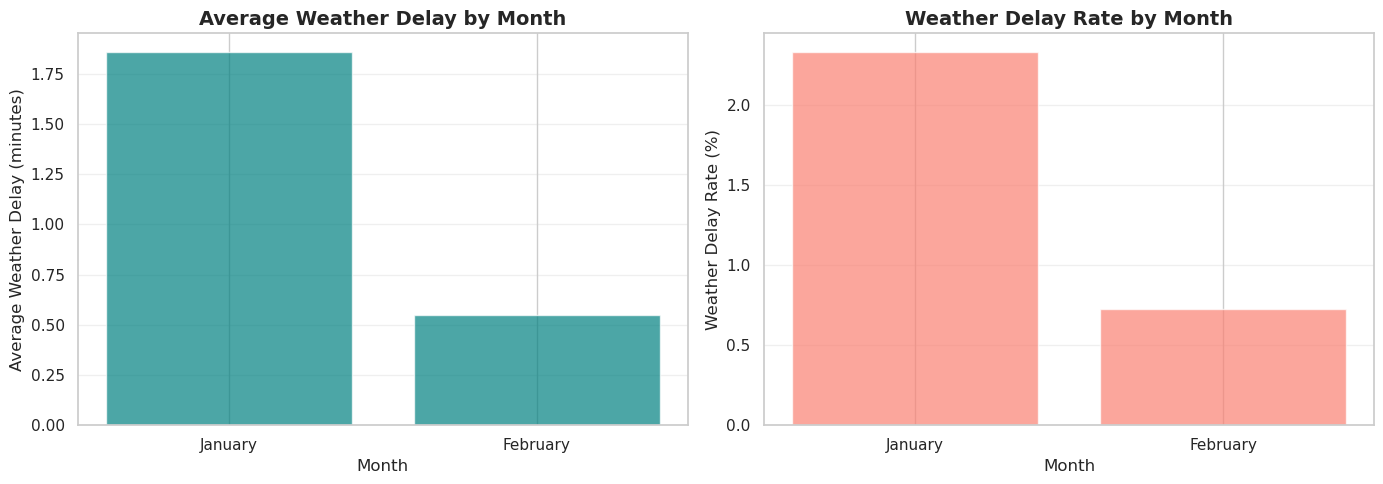

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_delay_month = df_q5.groupby('month')['weather_delay'].mean()
axes[0].bar(avg_delay_month.index, avg_delay_month.values, color='teal', alpha=0.7)
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Average Weather Delay (minutes)', fontsize=12)
axes[0].set_title('Average Weather Delay by Month', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticks(avg_delay_month.index)
axes[0].set_xticklabels(['January', 'February'])

# Delay rate by month
delay_rate_month = df_q5.groupby('month')['has_weather_delay'].mean() * 100
axes[1].bar(delay_rate_month.index, delay_rate_month.values, color='salmon', alpha=0.7)
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Weather Delay Rate (%)', fontsize=12)
axes[1].set_title('Weather Delay Rate by Month', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(delay_rate_month.index)
axes[1].set_xticklabels(['January', 'February'])

plt.tight_layout()
plt.show()


 **NOTE: Monthly Comparison**
   - Month 1 experiences higher weather delays with an average of ~1.8 minutes compared to Month 2 with ~0.55 minutes
   - The weather delay rate in Month 1 is ~2.3% compared to 0.7% in Month 2

**Visualization 3: Heatmap - Day of week × Month interaction**

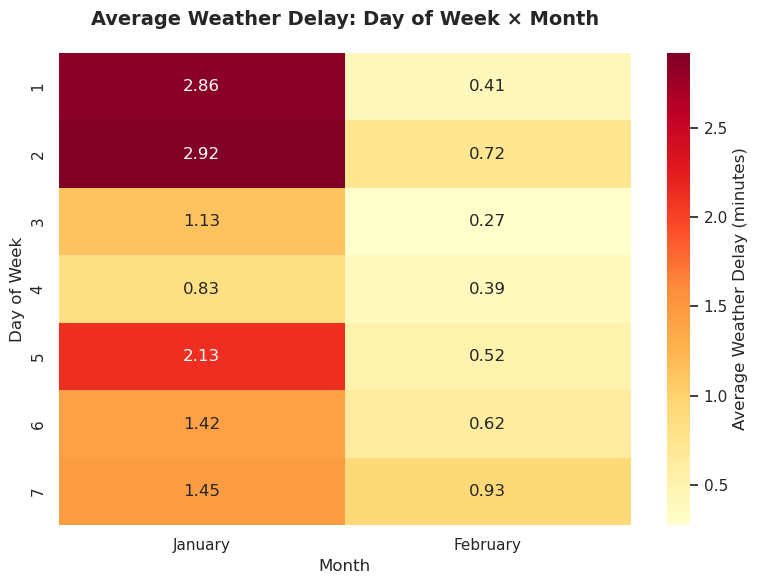

In [104]:
pivot_avg_delay = pd.pivot_table(
    df_q5,
    values='weather_delay',
    index='day_of_week',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_avg_delay, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Average Weather Delay (minutes)'})
plt.title('Average Weather Delay: Day of Week × Month', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.xticks([0.5, 1.5], ['January', 'February'])
plt.tight_layout()
plt.show()


**NOTE: Day × Month Interactions**
* Significant Monthly Difference: There is a stark contrast between the two months. January consistently experiences much higher average weather delays compared to February across all days of the week.

* Peak Delay Periods: The highest delays occur in early January, specifically on Day 2 (2.92 minutes) and Day 1 (2.86 minutes). These are the "hottest" zones on the heatmap (darkest red).

* Secondary Spike: In January, there is another notable increase in delays on Day 5 (2.13 minutes), while Days 3 and 4 show a relative mid-week dip.

* Lowest Delay Periods: February is much more stable and clear. The minimum delay recorded is on Day 3 of February (0.27 minutes).

* February Trend: Unlike January, February shows a slight upward trend toward the end of the week, peaking on Day 7 (0.93 minutes), though this is still significantly lower than any day in January.

**Visualization 4: Box plot - Distribution of weather delays by day of week (for flights with delays > 0)**

/tmp/ipykernel_20966/2561804312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=delayed_flights, x='day_of_week', y='weather_delay', palette='Set2')


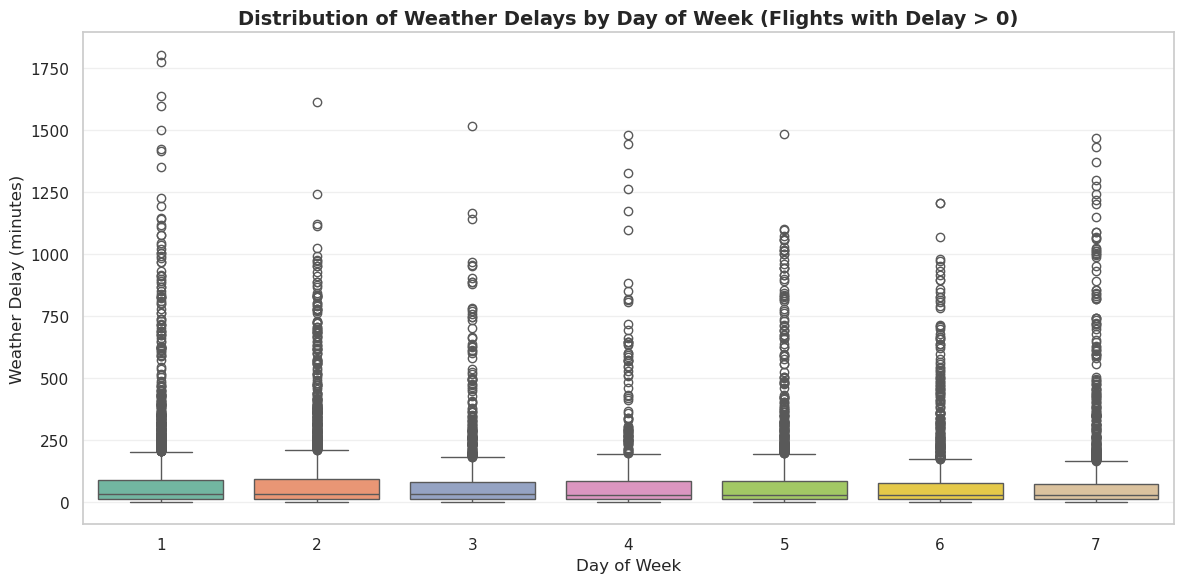

In [105]:
delayed_flights = df_q5[df_q5['weather_delay'] > 0]

plt.figure(figsize=(12, 6))
sns.boxplot(data=delayed_flights, x='day_of_week', y='weather_delay', palette='Set2')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Weather Delay (minutes)', fontsize=12)
plt.title('Distribution of Weather Delays by Day of Week (Flights with Delay > 0)', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**NOTE**

* Heavily Right-Skewed Distribution: Across all days of the week, weather delays are heavily right-skewed. While the majority of delayed flights have relatively short delays, there is a significant "long tail" of extreme events.

* Consistency in Median Delays: The median delay (represented by the line inside each box) remains remarkably consistent across all seven days, typically staying well below 100 minutes.

* Extreme Outliers: The most prominent feature of the chart is the high number of outliers. Weather events can cause massive disruptions, with some delays exceeding 1,500 minutes (25+ hours).

* Peak Disruptions on Day 1: Day 1 shows the highest extreme outliers, with some flights being delayed for nearly 1,800 minutes.

* Interquartile Range (IQR): The boxes (representing the middle 50% of the data) are similar in size for all days, suggesting that the "typical" delay behavior doesn't change much based on the day of the week, even if the extreme cases do.

Insight:

* **Extreme Events:** Every day of the week experiences significant outliers, indicating that weather-related disruptions are unpredictable and can be severe regardless of the day.
* **Worst Day for Extremes:** **Day 1** exhibits the most severe outliers, peaking near **1,800 minutes**, followed closely by Day 2 and Day 4.
* **Reliability:** Despite the outliers, the "typical" weather delay (the box area) is fairly uniform, suggesting a stable baseline of weather-related operational impacts.

**Visualization 5: Line chart day of month vs avg weather delay in January and February**

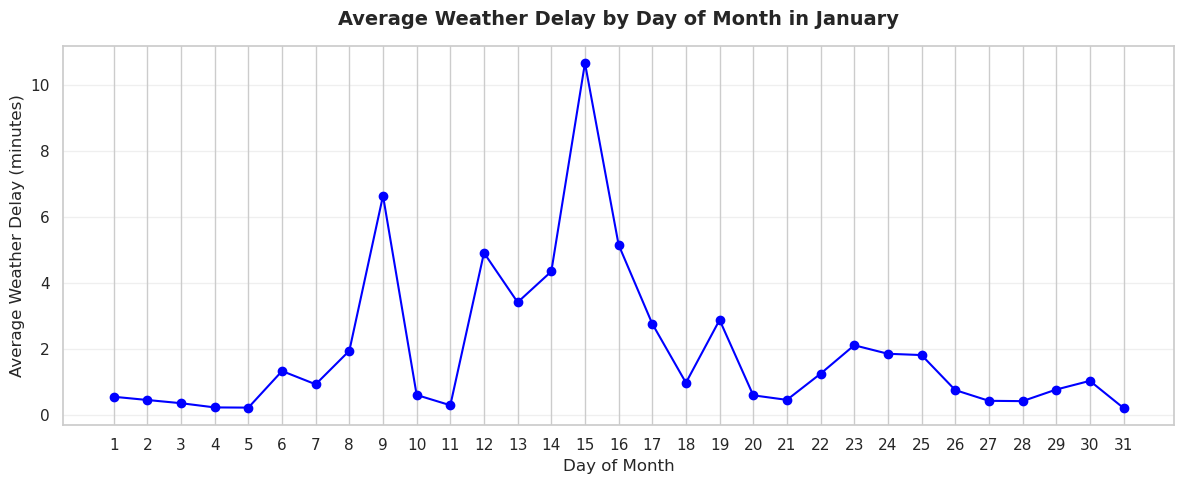

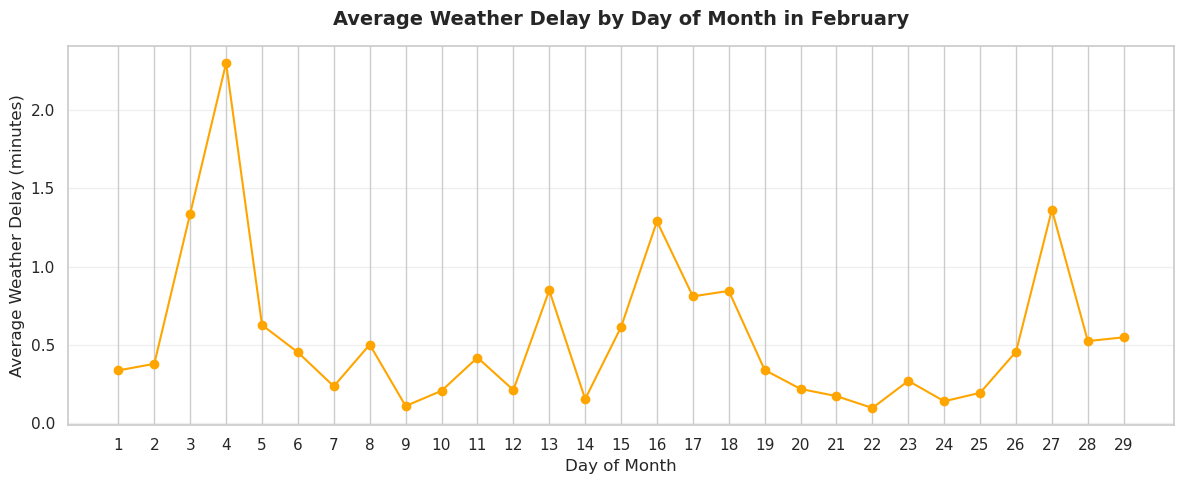

In [106]:
# Line chart day of month vs avg weather delay in January
january_data = df_q5[df_q5['month'] == 1]
avg_delay_dom_jan = january_data.groupby('day_of_month')['weather_delay'].mean()
plt.figure(figsize=(12, 5))
plt.plot(avg_delay_dom_jan.index, avg_delay_dom_jan.values, marker='o', color='blue')
plt.xlabel('Day of Month', fontsize=12)
plt.ylabel('Average Weather Delay (minutes)', fontsize=12)
plt.title('Average Weather Delay by Day of Month in January', fontsize=14, fontweight='bold', pad=15)
plt.xticks(avg_delay_dom_jan.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Line chart day of month vs avg weather delay in February
february_data = df_q5[df_q5['month'] == 2]
avg_delay_dom_feb = february_data.groupby('day_of_month')['weather_delay'].mean()
plt.figure(figsize=(12, 5))
plt.plot(avg_delay_dom_feb.index, avg_delay_dom_feb.values, marker='o', color='orange')
plt.xlabel('Day of Month', fontsize=12)
plt.ylabel('Average Weather Delay (minutes)', fontsize=12)
plt.title('Average Weather Delay by Day of Month in February', fontsize=14, fontweight='bold', pad=15)
plt.xticks(avg_delay_dom_feb.index)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**NOTE**

Analysis of the distribution of weather delays across the week reveals a highly skewed pattern:
* **Median Stability:** The median delay remains consistently low across all days, typically under 50 minutes.
* **Extreme Outliers:** All days exhibit significant outliers, indicating that weather disruptions are severe and unpredictable.
* **Maximum Impact:** Day 1 (Monday) shows the most extreme disruption, with individual delays peaking near **1,800 minutes**.

**Temporal Trends (Monthly Comparison)**

January Analysis
* **Peak Volatility:** January experiences massive spikes in average delays.
* **Critical Date:** January 15th recorded the highest average delay of the month at approximately **10.8 minutes**.
* **Mid-Month Surge:** A period of high instability is observed between the 9th and 19th.

February Analysis
* **Reduced Severity:** February is significantly calmer than January, with the highest average delay peaking at only **2.3 minutes** (Day 4).
* **Lower Baseline:** Most days in February maintain an average delay below 1 minute, suggesting better weather conditions or improved operational recovery.

**Visualization 6: Side-by-side comparison - January vs February by day of week**

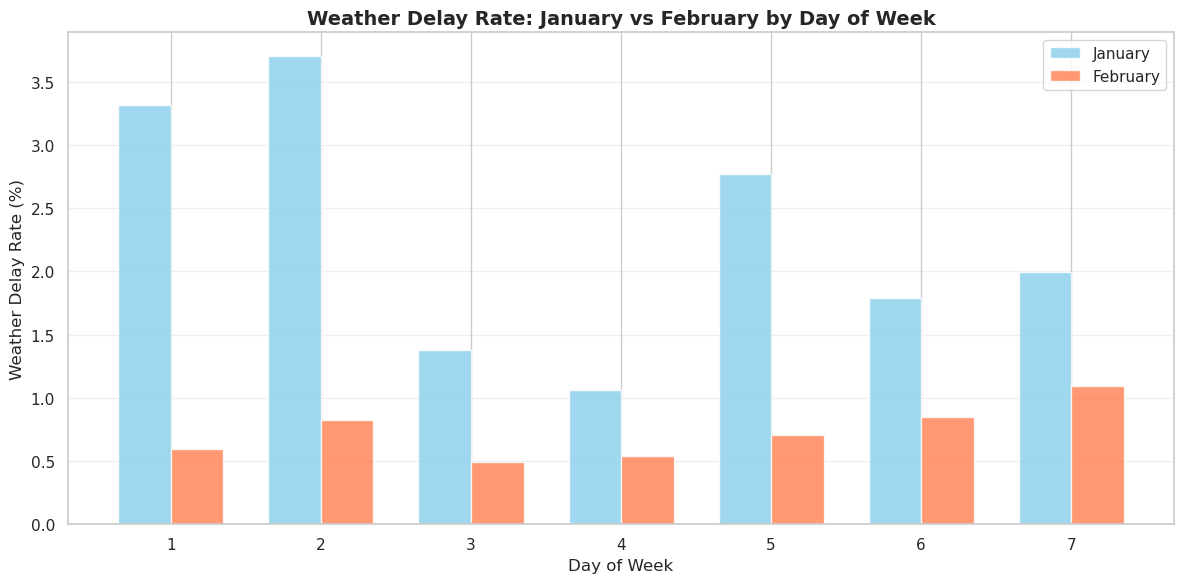

In [107]:
pivot_delay_rate = pd.pivot_table(
    df_q5,
    values='has_weather_delay',
    index='day_of_week',
    columns='month',
    aggfunc='mean'
) * 100

x = np.arange(len(pivot_delay_rate.index))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, pivot_delay_rate[1], width, label='January', alpha=0.8, color='skyblue')
bars2 = ax.bar(x + width/2, pivot_delay_rate[2], width, label='February', alpha=0.8, color='coral')

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Weather Delay Rate (%)', fontsize=12)
ax.set_title('Weather Delay Rate: January vs February by Day of Week', 
              fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot_delay_rate.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## **Question 6: How does flight volume vary by origin airport across different days and weeks?**

**The question:** How do flight volumes from different origin airports change over time (by day of week, day of month, and between months), and what patterns exist in airport activity levels?



### **A. Preprocessing**

##### Explanation

**Preprocessing steps**

1. **Data Preparation:**
   - Use all flights (including cancelled) since we're analyzing flight volume, not delays
   - Focus on `origin` airport as the primary grouping variable
   - Use `day_of_week`, `day_of_month`, and `month` as temporal grouping variables

2. **Feature Engineering:**
   - Count flights by origin airport to identify airport size
   - Group flights by origin and temporal variables (day_of_week, day_of_month, month)
   - Calculate flight volume metrics (total count, average per day)

3. **Airport Categorization:**
   - Identify top airports by total flight volume
   - Categorize airports into size tiers (large, medium, small) for comparative analysis
   - Select representative airports for detailed analysis

4. **Temporal Aggregation:**
   - Aggregate flight counts by origin × day_of_week
   - Aggregate flight counts by origin × day_of_month (for line chart)
   - Aggregate flight counts by origin × month
   - Create time series data for daily flight volume visualization

**Expected Outputs:**
- Flight volume distribution by origin airport
- Flight volume patterns by day of week for different airports
- Daily flight volume trends (line chart) for top airports
- Monthly comparison of flight volumes by airport


In [108]:
# Step 1: Prepare data - use all flights (including cancelled) for volume analysis
df_q6 = df_clean.copy()

print(f"Total flights for volume analysis: {len(df_q6):,}")

# Step 2: Calculate total flight volume by origin airport
flight_volume_by_origin = df_q6['origin'].value_counts().sort_values(ascending=False)

print(f"\nTotal number of origin airports: {len(flight_volume_by_origin)}")
print(f"\nTop 10 airports by flight volume:")
print(flight_volume_by_origin.head(10))

# Step 3: Identify airport size categories
total_flights = len(df_q6)
large_threshold = total_flights * 0.05  # Top 5% of airports
medium_threshold = total_flights * 0.01  # Top 1% of airports

large_airports = flight_volume_by_origin[flight_volume_by_origin >= large_threshold].index.tolist()
medium_airports = flight_volume_by_origin[
    (flight_volume_by_origin >= medium_threshold) & 
    (flight_volume_by_origin < large_threshold)
].index.tolist()
small_airports = flight_volume_by_origin[flight_volume_by_origin < medium_threshold].index.tolist()

print(f"\nAirport size categories:")
print(f"Large airports (≥{large_threshold:,.0f} flights): {len(large_airports)} airports")
print(f"Medium airports ({medium_threshold:,.0f}-{large_threshold:,.0f} flights): {len(medium_airports)} airports")
print(f"Small airports (<{medium_threshold:,.0f} flights): {len(small_airports)} airports")


Total flights for volume analysis: 1,041,174

Total number of origin airports: 334

Top 10 airports by flight volume:
origin
ATL    50212
DFW    45309
DEN    43900
ORD    38560
CLT    31575
PHX    29576
LAX    28675
LAS    28315
MCO    27237
LGA    24565
Name: count, dtype: int64

Airport size categories:
Large airports (≥52,059 flights): 0 airports
Medium airports (10,412-52,059 flights): 30 airports
Small airports (<10,412 flights): 304 airports


In [109]:
# Step 4: Flight volume by origin and day of week
volume_by_origin_dow = df_q6.groupby(['origin', 'day_of_week']).size().reset_index(name='flight_count')
top_10_airports = flight_volume_by_origin.head(10).index

volume_top10_dow = volume_by_origin_dow[volume_by_origin_dow['origin'].isin(top_10_airports)]
pivot_volume_dow = volume_top10_dow.pivot(index='origin', columns='day_of_week', values='flight_count')

print(pivot_volume_dow.round(0))


day_of_week     1     2     3     4     5     6     7
origin                                               
ATL          7749  7538  7563  7184  7094  6150  6934
CLT          4926  4373  4919  4455  4362  4164  4376
DEN          7002  6334  6421  6312  6299  5397  6135
DFW          7149  6578  6595  6521  6428  5638  6400
LAS          4674  3903  3910  4200  4251  3145  4232
LAX          4512  4245  4244  4086  4080  3467  4041
LGA          4024  3801  4057  3732  3549  2060  3342
MCO          4229  3823  3853  3803  3785  3838  3906
ORD          6013  5691  5911  5556  5345  4709  5335
PHX          4699  4317  4313  4222  4189  3631  4205


In [110]:
# Step 5: Flight volume by origin and day of month (for line chart)
volume_by_origin_day = df_q6.groupby(['origin', 'day_of_month']).size().reset_index(name='flight_count')
top_5_airports = flight_volume_by_origin.head(5).index

volume_top5_day = volume_by_origin_day[volume_by_origin_day['origin'].isin(top_5_airports)]
print(f"Data prepared for {len(top_5_airports)} airports across {volume_top5_day['day_of_month'].nunique()} days")
print(f"\nSample data (first 20 rows):")
print(volume_top5_day.head(20))


Data prepared for 5 airports across 31 days

Sample data (first 20 rows):
    origin  day_of_month  flight_count
540    ATL             1          1617
541    ATL             2          1740
542    ATL             3          1591
543    ATL             4          1713
544    ATL             5          1700
545    ATL             6          1594
546    ATL             7          1673
547    ATL             8          1713
548    ATL             9          1697
549    ATL            10          1586
550    ATL            11          1671
551    ATL            12          1667
552    ATL            13          1528
553    ATL            14          1582
554    ATL            15          1799
555    ATL            16          1758
556    ATL            17          1642
557    ATL            18          1736
558    ATL            19          1827
559    ATL            20          1633


In [111]:
# Step 6: Flight volume by origin and month
volume_by_origin_month = df_q6.groupby(['origin', 'month']).size().reset_index(name='flight_count')
volume_top10_month = volume_by_origin_month[volume_by_origin_month['origin'].isin(top_10_airports)]
pivot_volume_month = volume_top10_month.pivot(index='origin', columns='month', values='flight_count')

print(pivot_volume_month.round(0))


month       1      2
origin              
ATL     26238  23974
CLT     16295  15280
DEN     22980  20920
DFW     23364  21945
LAS     14805  13510
LAX     15051  13624
LGA     12427  12138
MCO     14150  13087
ORD     19713  18847
PHX     15274  14302


### **B. Analysis**

##### Explanation

**Analytical Approach for Question 6:**

This is an **exploratory data analysis (EDA)** question focusing on understanding temporal patterns in flight volumes across different airports.

**Methods:**
1. **Descriptive statistics:**
   - Calculate total flight volume by origin airport
   - Calculate average flight volume by day of week for each airport
   - Calculate average flight volume by day of month for each airport
   - Compare flight volumes between months for each airport

2. **Comparative analysis:**
   - Compare flight volume patterns across different airports
   - Identify airports with consistent vs. variable flight volumes
   - Compare weekly patterns (day_of_week) across airports
   - Compare monthly patterns across airports

3. **Visualization:**
   - Bar chart showing total flight volume by origin airport (top airports)
   - Bar chart showing flight volume by day of week for top airports
   - Line chart showing daily flight volume trends for top airports (day_of_month)
   - Heatmap showing origin × day_of_week flight volume patterns
   - Comparison chart showing flight volume by month for top airports

**Expected Outputs:**
- Identification of busiest airports and their activity patterns
- Weekly patterns in flight volumes (which days are busiest)
- Daily trends in flight volumes across the month
- Monthly variations in flight volumes
- Patterns that distinguish large vs. small airports


**Analysis 1: Average flight volume per day of week by airport (Top 10)**

In [112]:
avg_volume_dow = volume_top10_dow.groupby(['origin', 'day_of_week'])['flight_count'].mean().reset_index()
avg_volume_dow_pivot = avg_volume_dow.pivot(index='origin', columns='day_of_week', values='flight_count')

print(avg_volume_dow_pivot.round(1))

# Find busiest day for each airport
print("\nBusiest day of week for each airport:")
for airport in top_10_airports:
    if airport in avg_volume_dow_pivot.index:
        busiest_day = avg_volume_dow_pivot.loc[airport].idxmax()
        busiest_volume = avg_volume_dow_pivot.loc[airport].max()
        print(f"{airport}: Day {busiest_day} ({busiest_volume:.1f} flights/day)")


day_of_week       1       2       3       4       5       6       7
origin                                                             
ATL          7749.0  7538.0  7563.0  7184.0  7094.0  6150.0  6934.0
CLT          4926.0  4373.0  4919.0  4455.0  4362.0  4164.0  4376.0
DEN          7002.0  6334.0  6421.0  6312.0  6299.0  5397.0  6135.0
DFW          7149.0  6578.0  6595.0  6521.0  6428.0  5638.0  6400.0
LAS          4674.0  3903.0  3910.0  4200.0  4251.0  3145.0  4232.0
LAX          4512.0  4245.0  4244.0  4086.0  4080.0  3467.0  4041.0
LGA          4024.0  3801.0  4057.0  3732.0  3549.0  2060.0  3342.0
MCO          4229.0  3823.0  3853.0  3803.0  3785.0  3838.0  3906.0
ORD          6013.0  5691.0  5911.0  5556.0  5345.0  4709.0  5335.0
PHX          4699.0  4317.0  4313.0  4222.0  4189.0  3631.0  4205.0

Busiest day of week for each airport:
ATL: Day 1 (7749.0 flights/day)
DFW: Day 1 (7149.0 flights/day)
DEN: Day 1 (7002.0 flights/day)
ORD: Day 1 (6013.0 flights/day)
CLT: Day 1 (4926.

**Analysis 2: Flight volume variation coefficient by airport**

In [113]:
volume_variability = df_q6.groupby('origin').size()
top_10_volumes = volume_variability.nlargest(10)

# Calculate coefficient of variation for daily volumes
daily_volumes = df_q6.groupby(['origin', 'day_of_month']).size()
cv_by_airport = daily_volumes.groupby('origin').agg(['mean', 'std'])
cv_by_airport['cv'] = (cv_by_airport['std'] / cv_by_airport['mean'] * 100).round(2)
cv_by_airport = cv_by_airport.sort_values('mean', ascending=False).head(10)

print("Coefficient of Variation (CV) for daily flight volumes:")
print(cv_by_airport[['mean', 'std', 'cv']])


Coefficient of Variation (CV) for daily flight volumes:
               mean         std     cv
origin                                
ATL     1619.741935  268.186374  16.56
DFW     1461.580645  245.743331  16.81
DEN     1416.129032  246.577066  17.41
ORD     1243.870968  208.918444  16.80
CLT     1018.548387  163.680754  16.07
PHX      954.064516  166.223531  17.42
LAX      925.000000  156.943514  16.97
LAS      913.387097  182.097351  19.94
MCO      878.612903  154.864387  17.63
LGA      792.419355  141.875949  17.90


### **C. Results & Interpretation**

##### Visualizations


**Visualization 1: Total flight volume by origin airport (Top 15)**

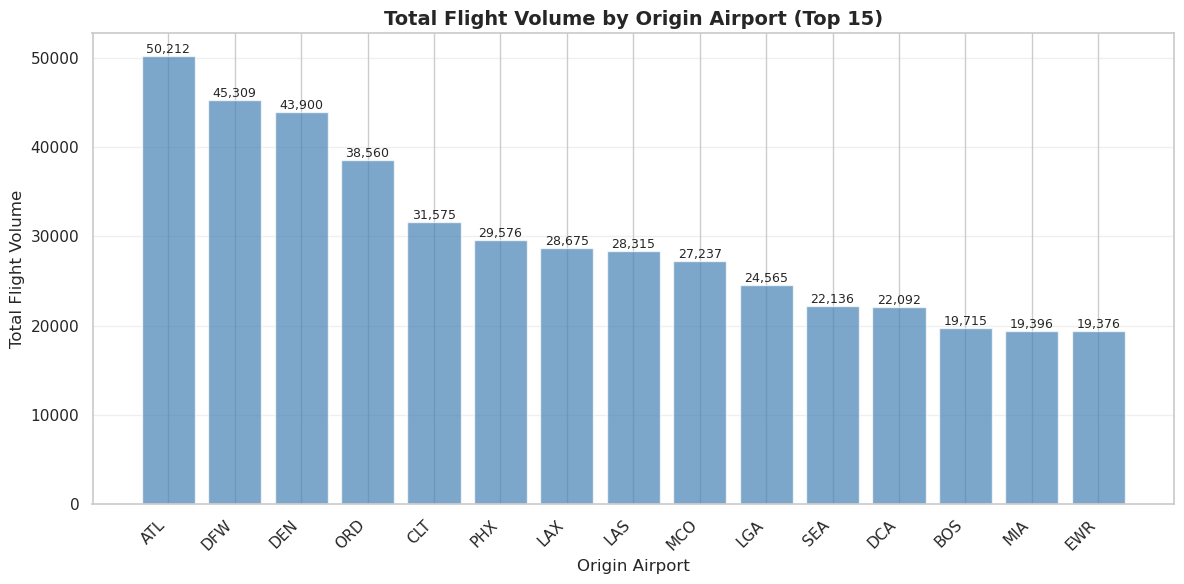

In [114]:
top_15_airports = flight_volume_by_origin.head(15)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_15_airports)), top_15_airports.values, color='steelblue', alpha=0.7)
plt.xlabel('Origin Airport', fontsize=12)
plt.ylabel('Total Flight Volume', fontsize=12)
plt.title('Total Flight Volume by Origin Airport (Top 15)', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_15_airports)), top_15_airports.index, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (airport, value) in enumerate(top_15_airports.items()):
    plt.text(i, value, f'{int(value):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


**NOTE**

Key Observations

* The Market Leader: ATL stands out as the busiest airport by a significant margin, recording 50,212 flights. It is the only airport in the dataset to surpass the 50,000-flight threshold.

* Three airports—ATL, DFW (45,309), and DEN (43,900)—form the top tier of the list, each handling over 40,000 flights.

* There is a noticeable decrease in volume after the fourth-ranked airport (ORD at 38,560). By the time the list reaches CLT (31,575), the volume has dropped by nearly 37% compared to the leader (ATL).

* The bottom three airports on this list (BOS, MIA, and EWR) show very similar volumes, clustered just below the 20,000 mark.

* Volume Comparison: The flight volume at ATL is approximately 2.6 times higher than that of EWR (19,376), highlighting the massive scale of operations at the top-ranked hub.

Conclusion: The data reflects a highly centralized flight network where a few "mega-hubs" (ATL, DFW, DEN) handle a disproportionately high volume of traffic compared to other major international airports.

**Visualization 2: Flight volume by day of week for top 10 airports**

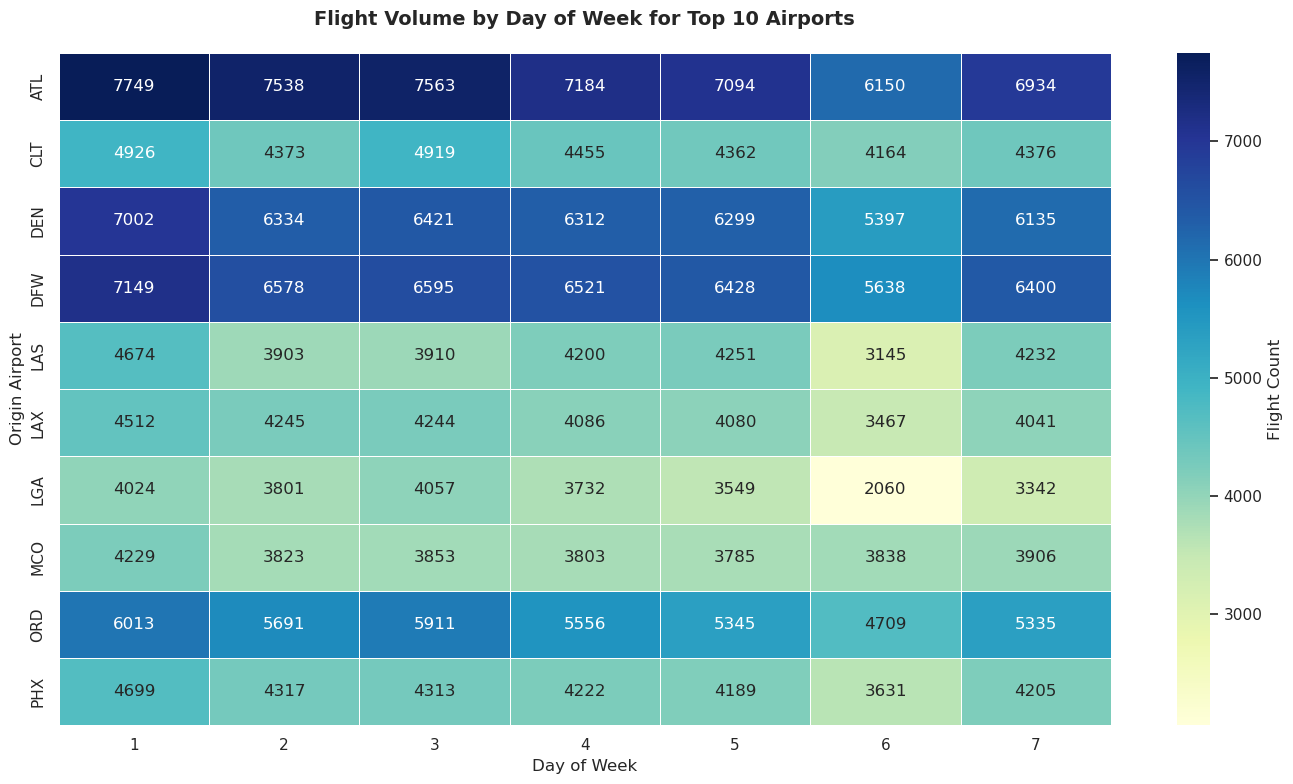

In [115]:
pivot_volume_dow_top10 = volume_top10_dow.pivot(index='origin', columns='day_of_week', values='flight_count')

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_volume_dow_top10, annot=True, fmt='.0f', cmap='YlGnBu', 
            cbar_kws={'label': 'Flight Count'}, linewidths=0.5)
plt.title('Flight Volume by Day of Week for Top 10 Airports', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Origin Airport', fontsize=12)
plt.tight_layout()
plt.show()


**NOTE**

* **Weekly Peak:** **Day 1** (Monday) serves as the peak travel day for almost all major hubs, with **ATL** reaching its highest point of **7,749** flights.
* **The "Saturday Slump":** **Day 6** consistently records the lowest flight volume across all 10 airports.
* **Business vs. Leisure Trends:**
    * **LGA (LaGuardia)** shows extreme volatility, with flights dropping from over 4,000 midweek to just **2,060** on Day 6, indicating a heavy business-travel focus.
    * **MCO (Orlando)** exhibits unique stability; its Day 6 volume (**3,838**) is actually higher than its Day 5 volume (**3,785**), reflecting its status as a major leisure destination.
* **Operational Stability:** **ATL** remains the most active hub every single day, never falling below **6,150** flights even on its quietest day.

**Visualization 3: Line chart - Daily flight volume trends for top 5 airports**

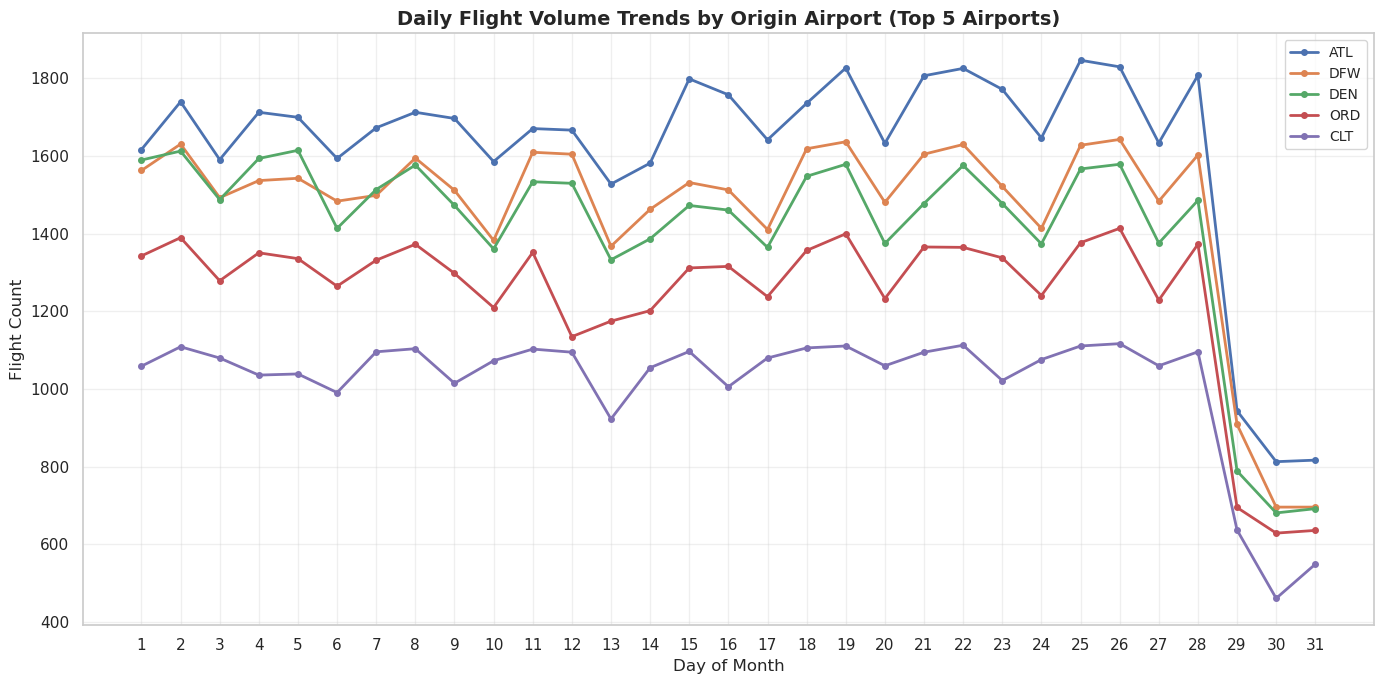

In [116]:
plt.figure(figsize=(14, 7))

for airport in top_5_airports:
    airport_data = volume_top5_day[volume_top5_day['origin'] == airport]
    airport_data = airport_data.sort_values('day_of_month')
    plt.plot(airport_data['day_of_month'], airport_data['flight_count'], 
             marker='o', label=airport, linewidth=2, markersize=4)

plt.xlabel('Day of Month', fontsize=12)
plt.ylabel('Flight Count', fontsize=12)
plt.title('Daily Flight Volume Trends by Origin Airport (Top 5 Airports)', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 32))
plt.tight_layout()
plt.show()


**NOTE**

* **ATL** remains at the top of the volume hierarchy throughout the entire month, followed by **DFW**, **DEN**, **ORD**, and **CLT** in a relatively stable order.
* The data shows a recurring 7-day pattern of "peaks and valleys," which aligns with the weekly business/leisure travel cycles observed in the heatmap.
* here is a dramatic and simultaneous decline in flight volumes across all five airports starting on **Day 29**. 
    * For instance, **ATL** drops from approximately **1,800** flights on Day 28 to roughly **800** flights by Day 30.
    * This sharp drop likely indicates a major external factor such as a severe weather event, a public holiday, or a data reporting cutoff.

**Visualization 4: Flight volume by month for top 10 airports**

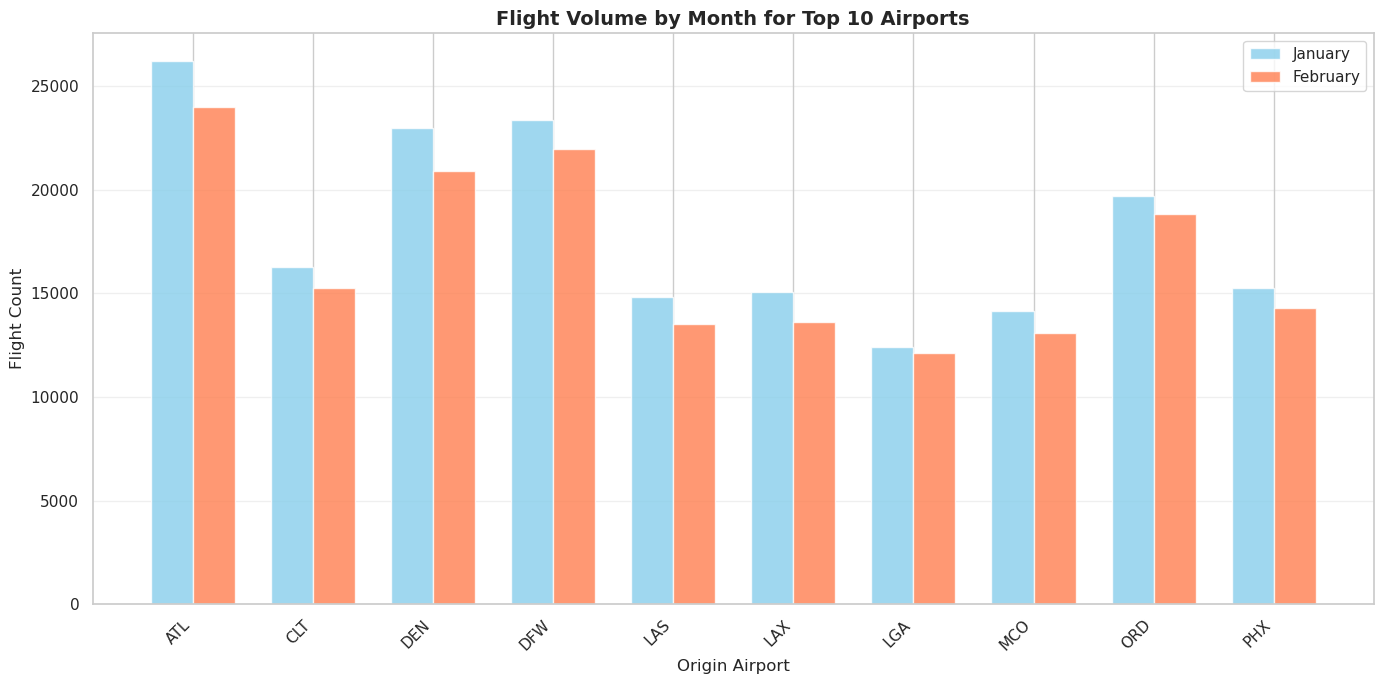

In [117]:
pivot_volume_month_top10 = volume_top10_month.pivot(index='origin', columns='month', values='flight_count')

x = np.arange(len(pivot_volume_month_top10.index))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, pivot_volume_month_top10[1], width, 
               label='January', alpha=0.8, color='skyblue')
bars2 = ax.bar(x + width/2, pivot_volume_month_top10[2], width, 
               label='February', alpha=0.8, color='coral')

ax.set_xlabel('Origin Airport', fontsize=12)
ax.set_ylabel('Flight Count', fontsize=12)
ax.set_title('Flight Volume by Month for Top 10 Airports', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot_volume_month_top10.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


**NOTE**

The grouped bar chart compares the total flight counts for the top 10 airports across the first two months of the year.

* Every airport in the top 10 experienced a decrease in flight volume in **February** compared to **January**. 
* **ATL** maintains the highest volume in both months, followed by **DFW** and **DEN**.
* Despite the overall volume drop, the relative ranking of the airports remains virtually unchanged between the two months.

**Visualization 5: Average flight volume per day of week (bar chart for top 10 airports)**

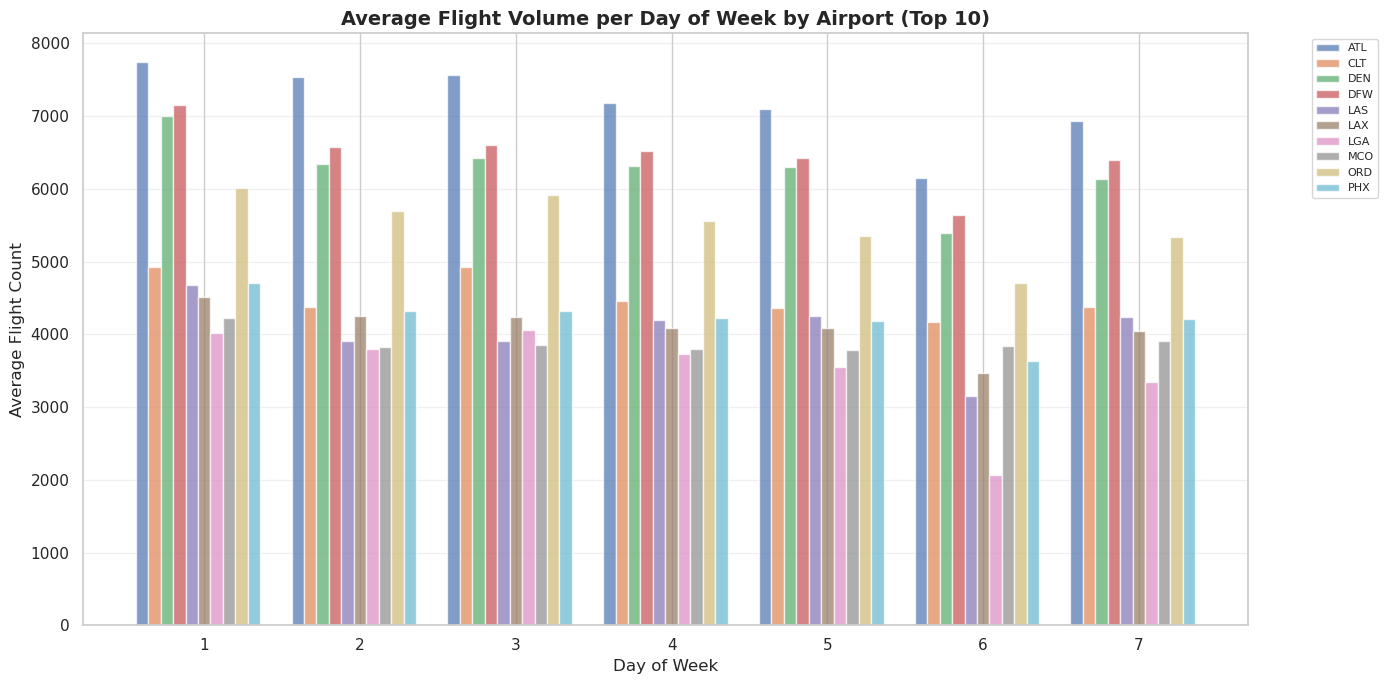

In [118]:
avg_volume_dow_pivot_top10 = avg_volume_dow_pivot.head(10)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(avg_volume_dow_pivot_top10.columns))
width = 0.08

for i, airport in enumerate(avg_volume_dow_pivot_top10.index):
    offset = (i - len(avg_volume_dow_pivot_top10.index)/2) * width
    ax.bar(x + offset, avg_volume_dow_pivot_top10.loc[airport], width, 
           label=airport, alpha=0.7)

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Flight Count', fontsize=12)
ax.set_title('Average Flight Volume per Day of Week by Airport (Top 10)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(avg_volume_dow_pivot_top10.columns)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


**NOTE**

* Average data shows that **Day 1** (Monday), **Day 3** (Wednesday), and **Day 5** (Friday) are generally the busiest days for major hubs like ATL, DFW, and DEN.
* **Day 6** (Saturday) is confirmed as the weekly low point for all airports, with **LGA** showing the most significant average drop-off compared to its weekday performance.
* The daily trend line shows a steady "sawtooth" pattern throughout the first 28 days of the month, indicating highly predictable weekly demand cycles.

# 5. Project summary
- **Each member:** What difficulties have you encountered?  
- **Each member:** What have you learned?  
- **Your group:** If you had more time, what would you do?


## Keys findings:
- List 3-5 most important insights from your analysis
- Highlight the most interesting or surprising discovery

## Limitations:
- Dataset limitations (sample size, biases, missing data)
- Analysis limitations (methodology constraints, unanswered aspects)
- Scope limitations (what you couldn't address)

## Future Directions (If You Had More Time)

- What additional questions would you explore?
- What deeper analysis would you conduct?
- What alternative methods or approaches would you try?
- What additional data would you seek?
- How could this work be expanded or improved?

## Individual Reflections
Each group member should write a personal reflection covering:
### Challenges & Difficulties Encountered:
- What specific obstacles did you face? (technical, analytical, conceptual)
- How did you overcome them?
- What was most challenging and why?
### Learning & Growth:
- What have you learned? (technical skills, analytical approaches, domain
knowledge)
- What surprised you most?
- How has this project shaped your understanding of data science?


# 6. References
- To finish this project, what materials have you consulted

# 7. Some general points:

- In notebook file, one important thing your group should try to practice is to **[organize sections](#)** and **[write/code clearly](#)**.  
  Your group should use Markdown headings to organize sections, and use Jupyter Notebook/Lab TOC to quickly navigate through headings (it’s similar to bookmark in pdf file).  
  During the process of writing/coding, try to maintain a calm mind, try to **[think for readers](#)**.

- In data science process your group needs to do, I think the most time-consuming part is **[from finding data to giving meaningful questions which can be answered with data](#)**.

